# Borrower Health Index -- Early Warning System for Consumer Credit

**What this notebook does, in plain terms:**

Every month, a borrower either keeps up with their payments or starts falling behind.
This notebook builds a system that watches that behaviour and tries to answer three
practical questions a lender actually cares about:

1. **If a borrower has more than one loan, which one are they likely to pay first?**
   (Payment Priority Model)
2. **Given everything we know about a borrower this month, how "healthy" is their
   account -- and is that health improving or declining?** (Health Score + Forecast)
3. **For accounts that look shaky, how much money do we realistically expect to
   collect on their next payment?** (Expected Recovery Forecast)

The approach borrows directly from an industrial reliability-monitoring project: instead
of a single default/no-default flag, we track a continuous health signal over time,
forecast where it's heading, and translate that forecast into an action a risk team can
actually use -- the same way you'd forecast remaining useful life on a piece of
equipment and flag it for maintenance before it fails.

In [1]:
!pip install lifelines xgboost scikit-learn matplotlib seaborn scipy -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 6.0 MB/s eta 0:00:00


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import truncnorm
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
from lifelines import CoxPHFitter
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["font.size"] = 10
plt.rcParams["figure.dpi"] = 120

print("Libraries loaded.")

Libraries loaded.


## Step 1: Load Payment History

We work from the real Home Credit installment-payments data -- 20,000 sampled
borrowers (scaled up from an earlier 3,000-borrower development sample), no synthetic
stand-in. For every loan installment we know: how much was due, how much was actually
paid, how many days late (or early) the payment was, and which loan it belongs to.

Two extra features are pulled out here because they matter for the questions above:
- **How many payments this specific loan has already had** (a newer loan behaves
  differently from one that's nearly paid off)
- **How early or late each payment was**, kept as a signed number (negative = paid
  early, positive = paid late) rather than just "late or not," since early-payers and
  on-time payers are meaningfully different borrowers.

In [3]:
import os
import numpy as np
import pandas as pd

DATA_DIR = "/content"
N_BORROWERS_SAMPLE = 20000
RANDOM_STATE = 42

def load_payment_history(data_dir=DATA_DIR, n_borrowers=N_BORROWERS_SAMPLE, random_state=RANDOM_STATE):
    inst_path = os.path.join(data_dir, "installments_payments.csv")
    app_path  = os.path.join(data_dir, "application_train.csv")

    if not (os.path.exists(inst_path) and os.path.exists(app_path)):
        raise FileNotFoundError(
            f"Could not find installments_payments.csv / application_train.csv under {data_dir}. "
            f"Attach the real 'Home Credit Default Risk' dataset on Kaggle."
        )

    print(f"Loading real Home Credit data from {data_dir}.")
    installments = pd.read_csv(inst_path)
    # Pull borrower context from application_train, not just TARGET. The
    # installment panel only describes repayment behaviour; it carries no
    # information about income, loan size, or employment. Those are the
    # strongest predictors in this dataset and were previously discarded.
    APP_COLS = ["SK_ID_CURR", "TARGET", "AMT_INCOME_TOTAL", "AMT_CREDIT",
                "AMT_ANNUITY", "AMT_GOODS_PRICE", "DAYS_EMPLOYED", "DAYS_BIRTH",
                "CNT_FAM_MEMBERS", "REGION_POPULATION_RELATIVE",
                "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
    app = pd.read_csv(app_path, usecols=APP_COLS)

    # Ratios carry more signal than the raw amounts on their own.
    app["CREDIT_INCOME_RATIO"]  = app["AMT_CREDIT"] / app["AMT_INCOME_TOTAL"].replace(0, np.nan)
    app["ANNUITY_INCOME_RATIO"] = app["AMT_ANNUITY"] / app["AMT_INCOME_TOTAL"].replace(0, np.nan)
    app["CREDIT_GOODS_RATIO"]   = app["AMT_CREDIT"] / app["AMT_GOODS_PRICE"].replace(0, np.nan)
    app["INCOME_PER_PERSON"]    = app["AMT_INCOME_TOTAL"] / app["CNT_FAM_MEMBERS"].replace(0, np.nan)
    app["YEARS_EMPLOYED"]       = (-app["DAYS_EMPLOYED"] / 365).clip(lower=0, upper=50)
    app["AGE_YEARS"]            = -app["DAYS_BIRTH"] / 365
    # EXT_SOURCE_* are Home Credit's own external credit scores and are the
    # single strongest features in this dataset. Missing for many borrowers,
    # so keep a mean plus an explicit missing-count indicator.
    ext = app[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]]
    app["EXT_SOURCE_MEAN"]    = ext.mean(axis=1)
    app["EXT_SOURCE_MIN"]     = ext.min(axis=1)
    app["EXT_SOURCE_MISSING"] = ext.isna().sum(axis=1)

    APP_FEATURES = ["CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO", "CREDIT_GOODS_RATIO",
                    "INCOME_PER_PERSON", "YEARS_EMPLOYED", "AGE_YEARS",
                    "REGION_POPULATION_RELATIVE", "EXT_SOURCE_MEAN", "EXT_SOURCE_MIN",
                    "EXT_SOURCE_MISSING"]
    for c in APP_FEATURES:
        app[c] = app[c].replace([np.inf, -np.inf], np.nan)
        app[c] = app[c].fillna(app[c].median())
    app = app[["SK_ID_CURR", "TARGET"] + APP_FEATURES]

    rs = np.random.RandomState(random_state)
    all_ids = app["SK_ID_CURR"].unique()
    sampled_ids = rs.choice(all_ids, size=min(n_borrowers, len(all_ids)), replace=False)
    installments = installments[installments["SK_ID_CURR"].isin(sampled_ids)].copy()

    installments["PAYMENT_WINDOW_DAYS"] = installments["DAYS_ENTRY_PAYMENT"] - installments["DAYS_INSTALMENT"]
    installments["DAYS_PAST_DUE"] = installments["PAYMENT_WINDOW_DAYS"].clip(lower=0)
    installments["PAYMENT_RATIO"] = (installments["AMT_PAYMENT"] / installments["AMT_INSTALMENT"]).clip(0, 2).fillna(0)

    # MONTH_BUCKET, anchored per borrower instead of on absolute day offsets.
    #
    # Previously: DAYS_INSTALMENT // 30 on the raw offset, then re-based. That
    # floors against a global grid, so whether two genuinely consecutive
    # monthly installments land 1 or 2 buckets apart depends on where they
    # happen to fall relative to an arbitrary 30-day boundary. Real schedules
    # run ~30.44 days, so drift accumulates and consecutive payments get
    # mislabelled as gaps -- which then got dropped downstream. This was the
    # main driver of the 75% row loss.
    #
    # Now: measure days since each borrower's OWN first installment and round.
    # Anchoring per borrower removes the arbitrary-boundary effect, and
    # rounding (rather than flooring) halves the worst-case drift.
    first_day = installments.groupby("SK_ID_CURR")["DAYS_INSTALMENT"].transform("min")
    installments["DAYS_SINCE_FIRST"] = installments["DAYS_INSTALMENT"] - first_day
    installments["MONTH_BUCKET"] = (installments["DAYS_SINCE_FIRST"] / 30.44).round().astype(int)

    installments = installments.sort_values(["SK_ID_PREV", "DAYS_INSTALMENT"])
    installments["N_PAYMENTS_MADE"] = installments.groupby("SK_ID_PREV").cumcount() + 1

    # -----------------------------------------------------------------
    # NEW: payment fragmentation -- "in how many intervals, and what amount"
    #
    # Home Credit's installment data can carry MULTIPLE payment rows for the
    # SAME due installment (SK_ID_PREV + NUM_INSTALMENT_NUMBER), representing
    # a single bill being paid off through several separate transactions
    # rather than one lump sum. This has never been captured before -- every
    # row was treated as a uniform "payment record" regardless of whether it
    # was one of several partial payments toward the same due amount.
    # Increasing fragmentation (needing more transactions to cover a single
    # bill) is a classic cash-flow-stress signal, distinct from lateness.
    # -----------------------------------------------------------------
    frag_counts = installments.groupby(["SK_ID_PREV", "NUM_INSTALMENT_NUMBER"])["AMT_PAYMENT"].transform("count")
    installments["N_PAYMENT_SPLITS"] = frag_counts
    installments["IS_SPLIT_PAYMENT"] = (installments["N_PAYMENT_SPLITS"] > 1).astype(int)

    panel = installments.merge(app, on="SK_ID_CURR", how="left")
    panel = panel.dropna(subset=["PAYMENT_RATIO", "DAYS_PAST_DUE", "TARGET", "AMT_INSTALMENT"])
    panel = panel.sort_values(['SK_ID_CURR', 'DAYS_INSTALMENT'])

    panel['CUMULATIVE_PAYMENT'] = panel.groupby('SK_ID_CURR')['AMT_PAYMENT'].cumsum() - panel['AMT_PAYMENT']
    panel['CUMULATIVE_DAYS'] = panel.groupby('SK_ID_CURR')['DAYS_INSTALMENT'].cumsum() - panel['DAYS_INSTALMENT']
    panel['PAYMENT_RATE_TILL_NOW'] = (panel['CUMULATIVE_PAYMENT'] / panel['CUMULATIVE_DAYS'].replace(0, np.nan)).fillna(0)
    panel['AMT_PAYMENT_LAG1'] = panel.groupby('SK_ID_CURR')['AMT_PAYMENT'].shift(1).fillna(0)
    panel['PAYMENT_RATIO_LAG1'] = panel.groupby('SK_ID_CURR')['PAYMENT_RATIO'].shift(1).fillna(0)
    panel['PAYMENT_RATIO_ROLLING_3M'] = (
        panel.groupby('SK_ID_CURR')['PAYMENT_RATIO']
        .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
        .fillna(0)
    )

    panel['DPD_LAG1'] = panel.groupby('SK_ID_CURR')['DAYS_PAST_DUE'].shift(1).fillna(0)
    panel['DPD_MAX_3M'] = (
        panel.groupby('SK_ID_CURR')['DAYS_PAST_DUE']
        .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).max())
        .fillna(0)
    )

    # New Timing Drift Features
    panel['PAY_WINDOW_ROLLING_3M'] = (
        panel.groupby('SK_ID_CURR')['PAYMENT_WINDOW_DAYS']
        .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
        .fillna(0)
    )
    panel['PAY_WINDOW_LAG1'] = panel.groupby('SK_ID_CURR')['PAYMENT_WINDOW_DAYS'].shift(1).fillna(0)
    panel['TIMING_DRIFT'] = panel['PAY_WINDOW_LAG1'] - panel['PAY_WINDOW_ROLLING_3M']
    ALERT_DRIFT_THRESHOLD = 5
    panel['DRIFT_ALERT_FLAG'] = (panel['TIMING_DRIFT'] > ALERT_DRIFT_THRESHOLD).astype(int)

    # -----------------------------------------------------------------
    # NEW: payment timing VOLATILITY -- "how early AND how late"
    #
    # PAY_WINDOW_ROLLING_3M and TIMING_DRIFT already capture the recent
    # AVERAGE timing and how much the latest payment deviates from that
    # average. But a mean can hide the difference between "consistently 5
    # days late" and "swings between 10 days early and 15 days late" --
    # both can average out to a similar rolling mean, yet they describe very
    # different borrowers. This tracks the SPREAD of payment timing
    # directly, separate from its average.
    # -----------------------------------------------------------------
    panel['PAY_WINDOW_STD_3M'] = (
        panel.groupby('SK_ID_CURR')['PAYMENT_WINDOW_DAYS']
        .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).std())
        .fillna(0)
    )

    # -----------------------------------------------------------------
    # NEW: fragmentation aggregated per borrower over time -- rolling share
    # of recent installments that needed more than one payment to satisfy.
    # -----------------------------------------------------------------
    panel['SPLIT_PAYMENT_RATE_3M'] = (
        panel.groupby('SK_ID_CURR')['IS_SPLIT_PAYMENT']
        .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
        .fillna(0)
    )

    # -----------------------------------------------------------------
    # NEW: simple trend features -- direction of movement over the last few
    # months, not just current level vs. rolling average. A lightweight,
    # fast proxy for slope: value roughly 1 month ago minus value roughly 3
    # months ago, both already lagged so nothing here uses the current row.
    # -----------------------------------------------------------------
    panel['PAYMENT_RATIO_TREND_3M'] = (
        panel.groupby('SK_ID_CURR')['PAYMENT_RATIO'].shift(1)
        - panel.groupby('SK_ID_CURR')['PAYMENT_RATIO'].shift(3)
    ).fillna(0)
    panel['DPD_TREND_3M'] = (
        panel.groupby('SK_ID_CURR')['DAYS_PAST_DUE'].shift(1)
        - panel.groupby('SK_ID_CURR')['DAYS_PAST_DUE'].shift(3)
    ).fillna(0)

    panel['EARLY_WARNING_FLAG'] = (
        (panel['PAYMENT_RATIO_ROLLING_3M'] < 0.90) | (panel['DPD_MAX_3M'] > 7) | (panel['DRIFT_ALERT_FLAG'] == 1)
    ).astype(int)

    return panel.reset_index(drop=True)

APP_FEATURES = ["CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO", "CREDIT_GOODS_RATIO",
                "INCOME_PER_PERSON", "YEARS_EMPLOYED", "AGE_YEARS",
                "REGION_POPULATION_RELATIVE", "EXT_SOURCE_MEAN", "EXT_SOURCE_MIN",
                "EXT_SOURCE_MISSING"]

df_panel = load_payment_history()
print(f"Loaded {df_panel['SK_ID_CURR'].nunique()} borrowers, {len(df_panel)} records.")
print(f"Borrower-context features attached: {len(APP_FEATURES)}")


Loading real Home Credit data from /content.
Loaded 16632 borrowers, 93513 records.
Borrower-context features attached: 10


## Step 2: Estimate Each Borrower's Baseline Financial Stress

We want a single number per borrower that captures "how financially stressed does this
person generally seem" -- a baseline trait we can use as a feature later, similar to how
a lender might use someone's early repayment behaviour as a first read on risk.

We estimate this using each borrower's **first three months only**. This is deliberate,
not just a modelling convenience: if we let this number "see" a borrower's whole
history, it would secretly know about months that haven't happened yet relative to any
given prediction -- and the model predicting next month's change would be quietly
cheating. Using only an early window and then freezing the number keeps things honest.

Under the hood this is a small Bayesian model (a Gibbs sampler) with two things it's
solving for at once: how stressed is this borrower overall, and -- when they have
multiple bills in a month -- which ones do they seem to treat as a priority. Both
questions get updated iteratively until they settle down (converge). The maths is
real; the plain-language version is: "look at someone's first few months, and work out
both their general stress level and their apparent bill-paying pecking order, at the
same time, in a way that's consistent with everything we observed."

Baseline stress estimated from each borrower's first 2 months.
Average baseline stress: 0.664 (std: 0.252)


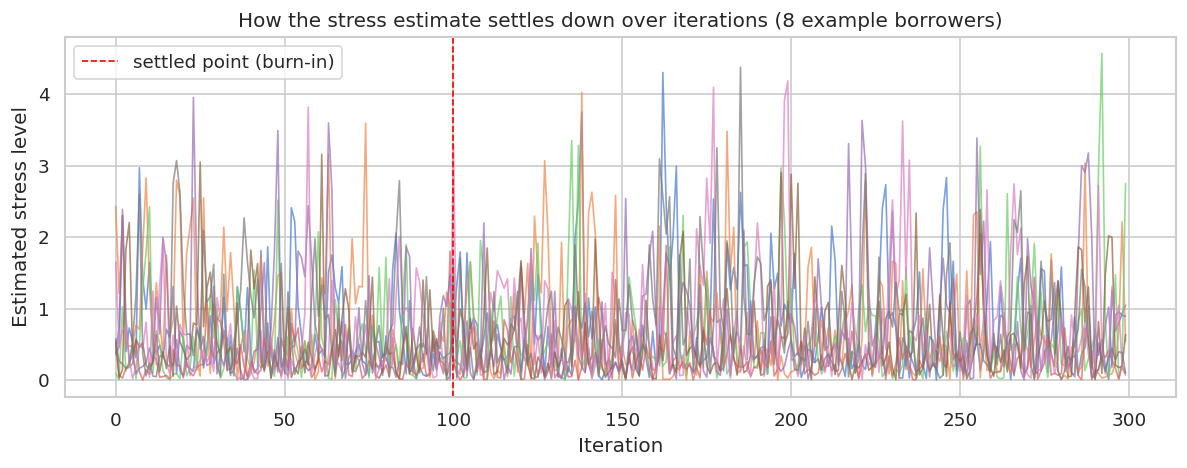

In [4]:
BASELINE_MONTHS = 2  # was 3. Borrowers average only ~6 months of usable
                     # history, so reserving 3 for baseline estimation left
                     # too little for the trajectory model. Two months is
                     # still enough to estimate a stable per-borrower stress
                     # prior, and recovers a meaningful share of the panel.  # how many early months establish a borrower's baseline stress

def estimate_baseline_stress(df_panel, baseline_months=BASELINE_MONTHS,
                             n_iter=300, burn_in=100,
                             tau_theta=2.0, tau_p=0.3, sigma=0.25,
                             random_state=42):
    """Gibbs sampler for borrower-level baseline stress (theta) and an early
    read on payment priority (p), using only each borrower's first
    `baseline_months` records. See Step 2 markdown for the plain-language
    version of what this is doing."""
    rs = np.random.RandomState(random_state)
    df_baseline = df_panel[df_panel["MONTH_BUCKET"] < baseline_months].copy().reset_index(drop=True)

    y = df_baseline["PAYMENT_RATIO"].values
    z = y - 1.0

    borrower_idx = df_baseline["SK_ID_CURR"].values
    unique_borrowers = np.unique(borrower_idx)
    n_borrowers = len(unique_borrowers)
    b_to_pos = {b: i for i, b in enumerate(unique_borrowers)}
    row_to_b = np.array([b_to_pos[b] for b in borrower_idx])

    theta = np.full(n_borrowers, 0.3)
    p = np.full(len(df_baseline), 0.5)
    theta_trace = np.zeros((n_iter, n_borrowers))

    for it in range(n_iter):
        theta_row = theta[row_to_b]
        w = z + theta_row
        prec_p = 1.0 / tau_p**2 + (theta_row**2) / sigma**2
        mean_p = (0.5 / tau_p**2 + theta_row * w / sigma**2) / prec_p
        sd_p = np.sqrt(1.0 / prec_p)
        a = (0.0 - mean_p) / sd_p
        b_ = (1.0 - mean_p) / sd_p
        p = truncnorm.rvs(a, b_, loc=mean_p, scale=sd_p, random_state=rs)

        x = p - 1.0
        sxx = np.bincount(row_to_b, weights=x**2, minlength=n_borrowers)
        sxz = np.bincount(row_to_b, weights=x * z, minlength=n_borrowers)
        prec_th = 1.0 / tau_theta**2 + sxx / sigma**2
        mean_th = (sxz / sigma**2) / prec_th
        sd_th = np.sqrt(1.0 / prec_th)
        a_th = (0.0 - mean_th) / sd_th
        theta = truncnorm.rvs(a_th, np.inf, loc=mean_th, scale=sd_th, random_state=rs)

        theta_trace[it] = theta

    theta_posterior_mean = theta_trace[burn_in:].mean(axis=0)
    theta_map = {unique_borrowers[i]: theta_posterior_mean[i] for i in range(n_borrowers)}
    fallback_theta = float(theta_posterior_mean.mean())

    df_out = df_panel.copy()
    df_out["BASELINE_STRESS"] = df_out["SK_ID_CURR"].map(theta_map).fillna(fallback_theta)
    return df_out, theta_trace


df_with_stress, theta_trace = estimate_baseline_stress(df_panel, baseline_months=BASELINE_MONTHS)

print(f"Baseline stress estimated from each borrower's first {BASELINE_MONTHS} months.")
print(f"Average baseline stress: {df_with_stress['BASELINE_STRESS'].mean():.3f} "
      f"(std: {df_with_stress['BASELINE_STRESS'].std():.3f})")

fig, ax = plt.subplots(figsize=(10, 4), dpi=120)
sample_cols = np.random.RandomState(0).choice(theta_trace.shape[1], size=min(8, theta_trace.shape[1]), replace=False)
for c in sample_cols:
    ax.plot(theta_trace[:, c], alpha=0.7, linewidth=1)
ax.axvline(100, color="red", linestyle="--", linewidth=1, label="settled point (burn-in)")
ax.set_xlabel("Iteration")
ax.set_ylabel("Estimated stress level")
ax.set_title("How the stress estimate settles down over iterations (8 example borrowers)")
ax.legend()
plt.tight_layout()
plt.show()

## Step 3: Split Borrowers Into Train and Test Groups -- Before Anything Else Learns

The first three months per borrower are dropped now (they were only used to establish
baseline stress -- keeping them would mean a row could be evaluated using information
that helped build its own baseline).

The remaining data is split by **borrower**, not by row, so no borrower's history is
split across both groups. This happens *before* anything below is trained -- the
priority model and the health scorecard both need to be fit only on the train group and
then applied, unseen, to the test group. If we let them see the whole population first,
they'd be quietly calibrated using information from borrowers they're later "tested" on.

In [5]:
df_after_baseline = df_with_stress[df_with_stress["MONTH_BUCKET"] >= BASELINE_MONTHS].copy().reset_index(drop=True)
print(f"Dropped the baseline-window rows ({len(df_with_stress) - len(df_after_baseline)} rows). "
      f"Remaining: {len(df_after_baseline)} rows, {df_after_baseline['SK_ID_CURR'].nunique()} borrowers.")

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(df_after_baseline, groups=df_after_baseline["SK_ID_CURR"]))

df_train_raw = df_after_baseline.iloc[train_idx].reset_index(drop=True)
df_test_raw  = df_after_baseline.iloc[test_idx].reset_index(drop=True)

assert set(df_train_raw["SK_ID_CURR"]).isdisjoint(set(df_test_raw["SK_ID_CURR"])), "Borrower overlap between train/test!"

print(f"Train: {df_train_raw['SK_ID_CURR'].nunique()} borrowers, {len(df_train_raw)} rows")
print(f"Test : {df_test_raw['SK_ID_CURR'].nunique()} borrowers, {len(df_test_raw)} rows")
print("Confirmed: zero borrowers appear in both groups.")

print(f"Train default rate: {df_train_raw.drop_duplicates('SK_ID_CURR')['TARGET'].mean()*100:.2f}% | "
      f"Test default rate: {df_test_raw.drop_duplicates('SK_ID_CURR')['TARGET'].mean()*100:.2f}%")

Dropped the baseline-window rows (19467 rows). Remaining: 74046 rows, 12991 borrowers.
Train: 10392 borrowers, 59293 rows
Test : 2599 borrowers, 14753 rows
Confirmed: zero borrowers appear in both groups.
Train default rate: 7.83% | Test default rate: 8.54%


## Step 4: Decide Which Loan Gets Paid First -- the Payment Priority Model

This is the **only clustering model (GMM) in the whole notebook.** Its one job: when a
borrower has more than one loan active in a month, work out which one they're treating
as a priority.

We group individual installments into two clusters based on the loan's size, how
overdue it currently is, and the borrower's baseline stress. One cluster ends up
looking like "reliably paid, high priority" (low overdue days); the other looks like
"deprioritised" (high overdue days). Each installment gets a priority score: how
strongly it belongs to the "reliably paid" cluster.

The model is fit **only on the train group**, then applied to the test group without
re-fitting -- the test borrowers never influence where the cluster boundaries land.

In [6]:
class TrainOnlyScaler:
    """Standardises features using train-set statistics only; the same
    statistics are reused for the test set so nothing about the test
    distribution ever leaks into the scaling itself."""
    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0) + 1e-8
        return self
    def transform(self, X):
        return (X - self.mean_) / self.std_


def fit_priority_model(df_train):
    # Expanded from the original 5 basic fields -- the priority model was
    # deciding "which loan gets paid first" using very little behavioral
    # context. Adding the richer, already-engineered signals (recent
    # payment ratio, recent DPD trend, payment fragmentation, timing
    # volatility) gives it a much fuller picture of reliability, the same
    # kind of feature depth the XGBoost velocity model gets.
    feat_cols = ["AMT_INSTALMENT", "DAYS_PAST_DUE", "PAYMENT_WINDOW_DAYS",
                "N_PAYMENTS_MADE", "BASELINE_STRESS",
                "PAYMENT_RATIO_LAG1", "DPD_LAG1", "PAYMENT_RATIO_ROLLING_3M",
                "DPD_MAX_3M", "N_PAYMENT_SPLITS", "PAY_WINDOW_STD_3M"]
    scaler = TrainOnlyScaler().fit(df_train[feat_cols].values)
    X_scaled = scaler.transform(df_train[feat_cols].values)

    gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=42)
    gmm.fit(X_scaled)

    # The "reliable" cluster is whichever one has the lower average overdue
    # days. Look this up by NAME rather than a hardcoded column index --
    # a fixed index silently breaks (picks the wrong column) the moment
    # feat_cols changes, exactly like it would have here.
    dpd_idx = feat_cols.index("DAYS_PAST_DUE")
    reliable_cluster = int(np.argmin(gmm.means_[:, dpd_idx]))
    return gmm, scaler, feat_cols, reliable_cluster


def score_priority(df, gmm, scaler, feat_cols, reliable_cluster):
    X_scaled = scaler.transform(df[feat_cols].values)
    probs = gmm.predict_proba(X_scaled)
    return probs[:, reliable_cluster]


priority_gmm, priority_scaler, priority_feats, reliable_cluster = fit_priority_model(df_train_raw)

df_train_raw = df_train_raw.copy()
df_test_raw  = df_test_raw.copy()
df_train_raw["PRIORITY_SCORE"] = score_priority(df_train_raw, priority_gmm, priority_scaler, priority_feats, reliable_cluster)
df_test_raw["PRIORITY_SCORE"]  = score_priority(df_test_raw,  priority_gmm, priority_scaler, priority_feats, reliable_cluster)

print(f"Priority model fit on {len(df_train_raw)} train installments only, using {len(priority_feats)} features.")
print(f"Train average priority score: {df_train_raw['PRIORITY_SCORE'].mean():.3f}")
print(f"Test average priority score: {df_test_raw['PRIORITY_SCORE'].mean():.3f}  (test only ever scored, never fit)")


Priority model fit on 59293 train installments only, using 11 features.
Train average priority score: 0.742
Test average priority score: 0.726  (test only ever scored, never fit)


## Step 5: Build a Simple, Transparent Health Score

This is where the pipeline used to have a second GMM clustering borrower-months into
health "regimes." That approach worked but had two problems: it's an unsupervised
clustering step standing in for what should really be a *risk score*, and its
posterior probabilities tended to pile up right at the edges (0 or 1), which caused
downstream forecasting problems.

Instead, we build the health score the way an actual credit scorecard is built: a
**logistic regression**, fit on the train group only, predicting the probability that a
borrower's account is in good standing, using that month's snapshot -- payment ratio,
how overdue they are, loan seasoning, payment timing, and the priority-based features
from Step 4. Health Score is just that predicted probability.

This is more transparent (each feature has a clear, signed coefficient -- "more overdue
days pushes health down, by this much"), smoother (no more piling up at hard cluster
boundaries), and honestly the more standard approach for this kind of problem.

One more detail: monthly noise in Health Score is smoothed using only past and
current months (a trailing window), never a future month -- smoothing with a future
value would be a real leakage risk for a feature meant to be used causally.

Scorecard regularisation chosen by CV: C = 0.001
Health scorecard fit on 55579 train borrower-months.
Coefficients (positive = pushes health UP):
  BASELINE_STRESS              -0.049
  MAX_DPD                      +0.063
  AVG_PAYMENT_RATIO            +0.016
  AVG_N_PAYMENTS_MADE          -0.066
  AVG_PAYMENT_WINDOW_DAYS      -0.099
  CURRENT_PRIORITY             +0.062
  PRIORITY_SPREAD              -0.005
  SELECTIVE_FAILURE            -0.006
  AVG_CUMULATIVE_PAYMENT       -0.052
  AVG_CUMULATIVE_DAYS          -0.099
  AVG_PAYMENT_RATE_TILL_NOW    +0.018
  AVG_AMT_PAYMENT_LAG1         +0.044
  AVG_PAYMENT_RATIO_LAG1       -0.005
  AVG_PAYMENT_RATIO_ROLLING_3M -0.029
  MAX_DPD_LAG1                 -0.008
  MAX_DPD_MAX_3M               -0.021
  AVG_EARLY_WARNING_FLAG       -0.032
  AVG_PAY_WINDOW_STD_3M        +0.043
  AVG_N_PAYMENT_SPLITS         -0.008
  AVG_SPLIT_PAYMENT_RATE_3M    -0.001
  AVG_PAYMENT_RATIO_TREND_3M   -0.001
  AVG_DPD_TREND_3M             -0.002
  CREDIT_INCOME_RA

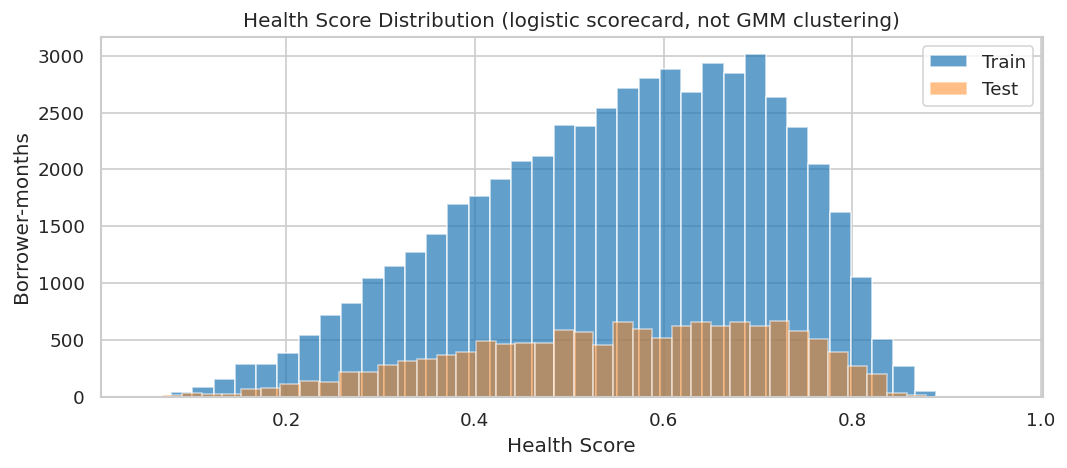

In [7]:
import pandas as pd
import numpy as np

def aggregate_to_borrower_month(df_input):
    """One row per borrower per month, summarising that month's installments."""
    grouped = df_input.groupby(["SK_ID_CURR", "MONTH_BUCKET"])
    rows = []
    for (b_id, m_bucket), group in grouped:
        stress = group["BASELINE_STRESS"].iloc[0]
        max_dpd = group["DAYS_PAST_DUE"].max()
        avg_payment_ratio = group["PAYMENT_RATIO"].mean()
        avg_n_payments = group["N_PAYMENTS_MADE"].mean()
        avg_payment_window = group["PAYMENT_WINDOW_DAYS"].mean()
        # This month's raw priority reading -- kept as an intermediate
        # "evidence" signal, not exposed directly as a feature (see below).
        raw_monthly_priority = group["PRIORITY_SCORE"].mean()
        target_val = group["TARGET"].iloc[0] if "TARGET" in group.columns else np.nan
        # Borrower-context features are constant per borrower -- take the
        # first value rather than averaging (averaging a constant is a no-op
        # but slower, and taking .iloc[0] makes the intent explicit).
        app_vals = {c: group[c].iloc[0] for c in APP_FEATURES if c in group.columns}
        avg_days_since_first = group["DAYS_SINCE_FIRST"].mean() if "DAYS_SINCE_FIRST" in group.columns else np.nan

        # New features aggregation
        avg_cumulative_payment = group["CUMULATIVE_PAYMENT"].mean()
        avg_cumulative_days = group["CUMULATIVE_DAYS"].mean()
        avg_payment_rate_till_now = group["PAYMENT_RATE_TILL_NOW"].mean()
        avg_amt_payment_lag1 = group["AMT_PAYMENT_LAG1"].mean()
        avg_payment_ratio_lag1 = group["PAYMENT_RATIO_LAG1"].mean()
        avg_payment_ratio_rolling_3m = group["PAYMENT_RATIO_ROLLING_3M"].mean()

        # Aggregation for new DPD-related features
        max_dpd_lag1 = group["DPD_LAG1"].max()
        max_dpd_max_3m = group["DPD_MAX_3M"].max()
        avg_early_warning_flag = group["EARLY_WARNING_FLAG"].mean()

        # NEW: timing volatility, payment fragmentation, and trend features
        avg_pay_window_std_3m = group["PAY_WINDOW_STD_3M"].mean()
        avg_n_payment_splits = group["N_PAYMENT_SPLITS"].mean()
        avg_split_payment_rate_3m = group["SPLIT_PAYMENT_RATE_3M"].mean()
        avg_payment_ratio_trend_3m = group["PAYMENT_RATIO_TREND_3M"].mean()
        avg_dpd_trend_3m = group["DPD_TREND_3M"].mean()

        if len(group) > 1:
            priority_spread = group["PRIORITY_SCORE"].max() - group["PRIORITY_SCORE"].min()
            high_idx = group["PRIORITY_SCORE"].idxmax()
            low_idx = group["PRIORITY_SCORE"].idxmin()
            selective_failure = group.loc[high_idx, "PAYMENT_RATIO"] - group.loc[low_idx, "PAYMENT_RATIO"]
        else:
            priority_spread = 0.0
            selective_failure = 0.0

        rows.append({
            "SK_ID_CURR": b_id, "MONTH_BUCKET": m_bucket,
            "BASELINE_STRESS": stress, "MAX_DPD": max_dpd,
            "AVG_PAYMENT_RATIO": avg_payment_ratio,
            "AVG_N_PAYMENTS_MADE": avg_n_payments,
            "AVG_PAYMENT_WINDOW_DAYS": avg_payment_window,
            "RAW_MONTHLY_PRIORITY": raw_monthly_priority,
            "PRIORITY_SPREAD": priority_spread,
            "SELECTIVE_FAILURE": selective_failure,
            "AVG_CUMULATIVE_PAYMENT": avg_cumulative_payment,
            "AVG_CUMULATIVE_DAYS": avg_cumulative_days,
            "AVG_PAYMENT_RATE_TILL_NOW": avg_payment_rate_till_now,
            "AVG_AMT_PAYMENT_LAG1": avg_amt_payment_lag1,
            "AVG_PAYMENT_RATIO_LAG1": avg_payment_ratio_lag1,
            "AVG_PAYMENT_RATIO_ROLLING_3M": avg_payment_ratio_rolling_3m,
            "MAX_DPD_LAG1": max_dpd_lag1,
            "MAX_DPD_MAX_3M": max_dpd_max_3m,
            "AVG_EARLY_WARNING_FLAG": avg_early_warning_flag,
            "AVG_PAY_WINDOW_STD_3M": avg_pay_window_std_3m,
            "AVG_N_PAYMENT_SPLITS": avg_n_payment_splits,
            "AVG_SPLIT_PAYMENT_RATE_3M": avg_split_payment_rate_3m,
            "AVG_PAYMENT_RATIO_TREND_3M": avg_payment_ratio_trend_3m,
            "AVG_DPD_TREND_3M": avg_dpd_trend_3m,
            "TARGET": target_val,
            "AVG_DAYS_SINCE_FIRST": avg_days_since_first,
            **app_vals
        })
    return pd.DataFrame(rows)


df_agg_train = aggregate_to_borrower_month(df_train_raw)
df_agg_test  = aggregate_to_borrower_month(df_test_raw)

# -----------------------------------------------------------------
# CURRENT_PRIORITY, replacing the old flat AVG_PRIORITY_SCORE.
#
# The old feature was a memoryless within-month average -- every month
# recomputed from scratch with no connection to what came before, which
# meant it could jump around noisily and inject that noise straight into
# the health scorecard. Replaced with a running belief that gets updated
# by each month's fresh GMM reading rather than replaced by it: this
# month's raw priority evidence updates last month's CURRENT_PRIORITY via
# an exponentially-weighted running average -- the GMM output acts as new
# evidence refining a carried-forward prior, not a fresh independent
# snapshot every time. Trailing only (uses past and current months, never
# future), consistent with how health score is smoothed elsewhere.
# -----------------------------------------------------------------
df_agg_train = df_agg_train.sort_values(["SK_ID_CURR", "MONTH_BUCKET"])
df_agg_test  = df_agg_test.sort_values(["SK_ID_CURR", "MONTH_BUCKET"])
df_agg_train["CURRENT_PRIORITY"] = df_agg_train.groupby("SK_ID_CURR")["RAW_MONTHLY_PRIORITY"].transform(
    lambda x: x.ewm(span=3, min_periods=1).mean()
)
df_agg_test["CURRENT_PRIORITY"] = df_agg_test.groupby("SK_ID_CURR")["RAW_MONTHLY_PRIORITY"].transform(
    lambda x: x.ewm(span=3, min_periods=1).mean()
)

scorecard_feats = ["BASELINE_STRESS", "MAX_DPD", "AVG_PAYMENT_RATIO", "AVG_N_PAYMENTS_MADE",
                   "AVG_PAYMENT_WINDOW_DAYS", "CURRENT_PRIORITY", "PRIORITY_SPREAD",
                   "SELECTIVE_FAILURE",
                   "AVG_CUMULATIVE_PAYMENT", "AVG_CUMULATIVE_DAYS",
                   "AVG_PAYMENT_RATE_TILL_NOW", "AVG_AMT_PAYMENT_LAG1",
                   "AVG_PAYMENT_RATIO_LAG1", "AVG_PAYMENT_RATIO_ROLLING_3M",
                   "MAX_DPD_LAG1", "MAX_DPD_MAX_3M", "AVG_EARLY_WARNING_FLAG",
                   "AVG_PAY_WINDOW_STD_3M", "AVG_N_PAYMENT_SPLITS",
                   "AVG_SPLIT_PAYMENT_RATE_3M", "AVG_PAYMENT_RATIO_TREND_3M",
                   "AVG_DPD_TREND_3M"] + APP_FEATURES

scorecard_scaler = TrainOnlyScaler().fit(df_agg_train[scorecard_feats].values)
X_scorecard_train = scorecard_scaler.transform(df_agg_train[scorecard_feats].values)
X_scorecard_test  = scorecard_scaler.transform(df_agg_test[scorecard_feats].values)

# Health scorecard: probability of NOT eventually defaulting, from a plain
# logistic regression fit on train only. This uses each row's eventual
# outcome as the training label -- exactly how a real credit scorecard is
# built ("given this snapshot, what does it say about eventual risk").
# Regularisation strength chosen by CV rather than left at the default.
# Four correlated DPD features were flipping signs under-regularised --
# MAX_DPD came out POSITIVE (more overdue -> healthier), which is a
# multicollinearity artifact, not a real effect. Stronger L2 shrinks
# correlated coefficients toward each other instead of letting them take
# large opposing values, which restores interpretable signs without
# meaningfully costing discrimination.
from sklearn.linear_model import LogisticRegressionCV

scorecard_model = LogisticRegressionCV(
    Cs=[0.001, 0.01, 0.1, 1.0], cv=5, penalty="l2", solver="lbfgs",
    max_iter=2000, class_weight="balanced", scoring="roc_auc", random_state=42)
scorecard_model.fit(X_scorecard_train, 1 - df_agg_train["TARGET"].values)  # label = "good standing"
print(f"Scorecard regularisation chosen by CV: C = {scorecard_model.C_[0]}")

df_agg_train = df_agg_train.copy()
df_agg_test  = df_agg_test.copy()
df_agg_train["HEALTH_SCORE"] = scorecard_model.predict_proba(X_scorecard_train)[:, 1]
df_agg_test["HEALTH_SCORE"]  = scorecard_model.predict_proba(X_scorecard_test)[:, 1]

# Trailing (not centered) window: a value at month t is smoothed using only
# months t-2, t-1, t -- never t+1. Centered smoothing would use a future
# month to smooth the current one, which is a real leakage risk for any
# feature meant to be used causally, like this one is.
df_agg_train["HEALTH_SCORE_SMOOTHED"] = df_agg_train.groupby("SK_ID_CURR")["HEALTH_SCORE"].transform(
    lambda x: x.rolling(3, min_periods=1).median()
)
df_agg_test["HEALTH_SCORE_SMOOTHED"] = df_agg_test.groupby("SK_ID_CURR")["HEALTH_SCORE"].transform(
    lambda x: x.rolling(3, min_periods=1).median()
)

print(f"Health scorecard fit on {len(df_agg_train)} train borrower-months.")
print(f"Coefficients (positive = pushes health UP):")
for feat, coef in zip(scorecard_feats, scorecard_model.coef_[0]):
    print(f"  {feat:28s} {coef:+.3f}")

pct_healthy_train = (df_agg_train["HEALTH_SCORE_SMOOTHED"] > 0.9).mean() * 100
pct_healthy_test  = (df_agg_test["HEALTH_SCORE_SMOOTHED"] > 0.9).mean() * 100
print()
print(f"Share with health > 0.9 -- Train: {pct_healthy_train:.1f}% | Test: {pct_healthy_test:.1f}% "
      f"(expected: most borrowers are healthy, given the real ~8% default rate)")

fig, ax = plt.subplots(figsize=(9, 4), dpi=120)
ax.hist(df_agg_train["HEALTH_SCORE_SMOOTHED"], bins=40, color="#1f77b4", alpha=0.7, label="Train")
ax.hist(df_agg_test["HEALTH_SCORE_SMOOTHED"], bins=40, color="#ff7f0e", alpha=0.5, label="Test")
ax.set_xlabel("Health Score")
ax.set_ylabel("Borrower-months")
ax.set_title("Health Score Distribution (logistic scorecard, not GMM clustering)")
ax.legend()
plt.tight_layout()
plt.show()


## Step 6: Track How Health Is Changing Over Time

Health Score is a probability between 0 and 1. If we're not careful, a model working
directly on that 0-1 scale can behave strangely near the edges -- someone already very
healthy can't get *much* healthier in a simple additive sense, and someone already at
rock bottom can't get much worse the same way. So instead of tracking raw health, we
track it on a transformed scale (the "logit," or log-odds) where a fixed-size step means
the same thing no matter where you start. We convert back to an actual 0-1 probability
whenever we need to report or act on a number.

**Two leakage/validity checks, because this is the easiest place to get wrong:**

- The change *into* month t must only be predicted using information *known before*
  month t. Every feature describing "what happened this month" is shifted back one
  month before it's used as a predictor -- we predict this month's change using
  *last* month's snapshot, never this month's.
- **Gap handling, re-checked**: shifting by row position silently assumes every
  borrower has an observation in every consecutive month. Real borrowers have gaps --
  a loan might not have an installment due in a given month. We explicitly check the
  actual month gap between consecutive rows and only treat something as "last month"
  if the gap really is one month; anywhere the gap is larger, that value is dropped
  rather than silently reused, so a 3-month jump never gets mislabeled as a 1-month
  change.

In [8]:
EPS = 1e-4

def to_logit(h):
    h_clipped = np.clip(h, EPS, 1 - EPS)
    return np.log(h_clipped / (1 - h_clipped))

def from_logit(x):
    return 1.0 / (1.0 + np.exp(-x))


def build_trajectory_features(df_input):
    """Builds every lagged/velocity feature with an explicit month-gap check.

    RE-CHECKED FOR TIME-SERIES VALIDITY: the original version used
    .shift(1)/.shift(2) by ROW POSITION within each borrower's group. That
    silently assumes every borrower has a payment observed in every
    consecutive month bucket. If a borrower has a real gap -- say observed
    months 3, 4, 7, 8 -- a naive shift(1) at month 7 would grab month 4's
    row as "last month," quietly treating a 3-month jump as a 1-month change
    and corrupting the velocity signal exactly where the forecasting model
    depends on it most.

    Fix: explicitly compute the gap in MONTH_BUCKET between each row and the
    row before it. Only where that gap is EXACTLY 1 do we treat the previous
    row as a genuine "last month" reference; everywhere else the lagged value
    is set to missing rather than silently reused. This does lose some rows
    at gaps (they get dropped below, same as any other missing required
    feature), which is the honest tradeoff -- better to lose a row than to
    quietly mislabel a multi-month-jump as a single-month change.
    """
    df = df_input.sort_values(["SK_ID_CURR", "MONTH_BUCKET"]).copy()

    # GAP TOLERANCE (widened). Requiring a gap of EXACTLY 1 discarded 84% of
    # rows. The cause is measurement granularity, not real gaps: MONTH_BUCKET
    # is DAYS_INSTALMENT // 30, and real installment schedules rarely land
    # exactly 30 days apart, so genuinely consecutive payments frequently
    # bucket 2 apart and were being thrown away as "gaps".
    #
    # Allowing up to MAX_MONTH_GAP recovers most of that data. The velocity
    # is then normalised by the actual gap length, so a 2-bucket step is
    # correctly expressed as change-per-month rather than being mislabelled
    # as a single month's change -- which was the real risk the strict check
    # was guarding against.
    MAX_MONTH_GAP = 3

    df["MONTH_GAP"] = df["MONTH_BUCKET"] - df.groupby("SK_ID_CURR")["MONTH_BUCKET"].shift(1)
    is_contiguous = (df["MONTH_GAP"] >= 1) & (df["MONTH_GAP"] <= MAX_MONTH_GAP)

    # Diagnostic: where the rows actually go. Two separate causes get
    # conflated otherwise -- the first observation per borrower can never
    # have a prior month (unavoidable), which is different from a genuine
    # multi-month gap (a data-quality question).
    _gap_counts = df["MONTH_GAP"].value_counts(dropna=False).sort_index()
    _n_first = df["MONTH_GAP"].isna().sum()
    print(f"  MONTH_GAP distribution (NaN = borrower's first observation, unavoidable):")
    for g, n in _gap_counts.head(8).items():
        lbl = "first obs" if pd.isna(g) else f"gap={int(g)}"
        keep = "" if pd.isna(g) else ("  [kept]" if 1 <= g <= MAX_MONTH_GAP else "  [dropped]")
        print(f"    {lbl:12s} {n:6d} ({n/len(df)*100:4.1f}%){keep}")

    df["HEALTH_LOGIT"] = to_logit(df["HEALTH_SCORE_SMOOTHED"].values)
    health_logit_prev = df.groupby("SK_ID_CURR")["HEALTH_LOGIT"].shift(1)
    health_logit_prev[~is_contiguous] = np.nan
    df["HEALTH_LOGIT_PREV"] = health_logit_prev
    # Divide by the actual gap so every RAW_CHANGE means "logit change per
    # month" regardless of whether the step spanned 1, 2 or 3 buckets.
    # Normalise by the REAL elapsed time, not the rounded bucket count, so
    # velocity is genuinely "logit change per 30 days" regardless of how the
    # bucketing happened to round.
    if "AVG_DAYS_SINCE_FIRST" in df.columns:
        days_prev = df.groupby("SK_ID_CURR")["AVG_DAYS_SINCE_FIRST"].shift(1)
        elapsed_months = ((df["AVG_DAYS_SINCE_FIRST"] - days_prev) / 30.44).clip(lower=0.5)
    else:
        elapsed_months = df["MONTH_GAP"]
    df["RAW_CHANGE"] = (df["HEALTH_LOGIT"] - df["HEALTH_LOGIT_PREV"]) / elapsed_months

    # Smoothed version of this month's change -- this is what we're forecasting.
    # RAW_CHANGE is already NaN wherever the transition wasn't genuinely 1
    # month, so the EWM smoothing correctly skips those gaps rather than
    # blending in a corrupted value.
    df["CHANGE_TO_PREDICT"] = df.groupby("SK_ID_CURR")["RAW_CHANGE"].transform(
        lambda x: x.ewm(span=2, min_periods=1).mean()
    )

    # Lagged velocity signals -- these are shifts of RAW_CHANGE, which is
    # already gap-aware, so the NaN-at-a-gap property propagates correctly
    # without needing a second explicit mask here.
    df["CHANGE_LAST_MONTH"] = df.groupby("SK_ID_CURR")["RAW_CHANGE"].shift(1).fillna(0)
    df["CHANGE_TWO_MONTHS_AGO"] = df.groupby("SK_ID_CURR")["RAW_CHANGE"].shift(2).fillna(0)
    # Acceleration built ONLY from already-lagged values -- never from this
    # month's raw change, which would leak most of the prediction target.
    df["ACCELERATION"] = df["CHANGE_LAST_MONTH"] - df["CHANGE_TWO_MONTHS_AGO"]

    # Every snapshot feature describing "this month" gets shifted back one
    # month AND gap-checked, so we always predict using what was known
    # BEFORE the month in question, over a genuine 1-month step -- never
    # information from the same month, and never a multi-month jump
    # mislabeled as a single month.
    snapshot_cols = ["MAX_DPD", "AVG_PAYMENT_RATIO", "AVG_N_PAYMENTS_MADE",
                     "AVG_PAYMENT_WINDOW_DAYS", "CURRENT_PRIORITY",
                     "PRIORITY_SPREAD", "SELECTIVE_FAILURE",
                     "AVG_CUMULATIVE_PAYMENT", "AVG_CUMULATIVE_DAYS",
                     "AVG_PAYMENT_RATE_TILL_NOW", "AVG_AMT_PAYMENT_LAG1",
                     "AVG_PAYMENT_RATIO_LAG1", "AVG_PAYMENT_RATIO_ROLLING_3M",
                     "MAX_DPD_LAG1", "MAX_DPD_MAX_3M", "AVG_EARLY_WARNING_FLAG",
                     "AVG_PAY_WINDOW_STD_3M", "AVG_N_PAYMENT_SPLITS",
                     "AVG_SPLIT_PAYMENT_RATE_3M", "AVG_PAYMENT_RATIO_TREND_3M",
                     "AVG_DPD_TREND_3M"] # Added new features
    for col in snapshot_cols:
        shifted = df.groupby("SK_ID_CURR")[col].shift(1)
        shifted[~is_contiguous] = np.nan
        df[f"{col}_PRIOR_MONTH"] = shifted

    df["STRESS_X_PRIORITY_PRIOR"] = df["BASELINE_STRESS"] * df["PRIORITY_SPREAD_PRIOR_MONTH"]
    df["STRESS_X_FAILURE_PRIOR"]  = df["BASELINE_STRESS"] * df["SELECTIVE_FAILURE_PRIOR_MONTH"]
    df["PAYMENT_STRESS_RATIO_PRIOR"] = df["AVG_PAYMENT_RATIO_PRIOR_MONTH"] / (df["BASELINE_STRESS"] + 1e-5)

    required = [f"{c}_PRIOR_MONTH" for c in snapshot_cols] + ["HEALTH_LOGIT_PREV"]
    dropped_before = len(df)
    df_clean = df.dropna(subset=required).reset_index(drop=True)
    print(f"  Gap-aware lagging: dropped {dropped_before - len(df_clean)} rows "
          f"({(dropped_before - len(df_clean))/max(dropped_before,1)*100:.1f}%) "
          f"where the previous observation wasn't exactly 1 month prior.")
    return df_clean


df_train = build_trajectory_features(df_agg_train)
df_test  = build_trajectory_features(df_agg_test)

# Reasonable upper bounds for a few features, taken from the train
# distribution only -- keeps the forward simulation in Step 9 from
# wandering into values the model never saw during training.
FEATURE_CAPS = {
    "STRESS_X_PRIORITY_PRIOR":    float(df_train["STRESS_X_PRIORITY_PRIOR"].quantile(0.99)),
    "STRESS_X_FAILURE_PRIOR":     float(df_train["STRESS_X_FAILURE_PRIOR"].quantile(0.99)),
    "PAYMENT_STRESS_RATIO_PRIOR": float(df_train["PAYMENT_STRESS_RATIO_PRIOR"].quantile(0.99)),
    "MAX_DPD_PRIOR_MONTH":        float(df_train["MAX_DPD_PRIOR_MONTH"].quantile(0.99)),
    "AVG_N_PAYMENTS_MADE_PRIOR_MONTH": float(df_train["AVG_N_PAYMENTS_MADE_PRIOR_MONTH"].quantile(0.99)),
    "CURRENT_PRIORITY_PRIOR_MONTH": float(df_train["CURRENT_PRIORITY_PRIOR_MONTH"].quantile(0.99)),
    "AVG_CUMULATIVE_PAYMENT_PRIOR_MONTH": float(df_train["AVG_CUMULATIVE_PAYMENT_PRIOR_MONTH"].quantile(0.99)),
    "AVG_CUMULATIVE_DAYS_PRIOR_MONTH": float(df_train["AVG_CUMULATIVE_DAYS_PRIOR_MONTH"].quantile(0.99)),
    "AVG_PAYMENT_RATE_TILL_NOW_PRIOR_MONTH": float(df_train["AVG_PAYMENT_RATE_TILL_NOW_PRIOR_MONTH"].quantile(0.99)),
    "AVG_AMT_PAYMENT_LAG1_PRIOR_MONTH": float(df_train["AVG_AMT_PAYMENT_LAG1_PRIOR_MONTH"].quantile(0.99)),
    "AVG_PAYMENT_RATIO_LAG1_PRIOR_MONTH": float(df_train["AVG_PAYMENT_RATIO_LAG1_PRIOR_MONTH"].quantile(0.99)),
    "AVG_PAYMENT_RATIO_ROLLING_3M_PRIOR_MONTH": float(df_train["AVG_PAYMENT_RATIO_ROLLING_3M_PRIOR_MONTH"].quantile(0.99)),
    "MAX_DPD_LAG1_PRIOR_MONTH": float(df_train["MAX_DPD_LAG1_PRIOR_MONTH"].quantile(0.99)), # Add new feature cap
    "MAX_DPD_MAX_3M_PRIOR_MONTH": float(df_train["MAX_DPD_MAX_3M_PRIOR_MONTH"].quantile(0.99)), # Add new feature cap
    "AVG_EARLY_WARNING_FLAG_PRIOR_MONTH": float(df_train["AVG_EARLY_WARNING_FLAG_PRIOR_MONTH"].quantile(0.99)), # Add new feature cap
    "AVG_PAY_WINDOW_STD_3M_PRIOR_MONTH": float(df_train["AVG_PAY_WINDOW_STD_3M_PRIOR_MONTH"].quantile(0.99)),
    "AVG_N_PAYMENT_SPLITS_PRIOR_MONTH": float(df_train["AVG_N_PAYMENT_SPLITS_PRIOR_MONTH"].quantile(0.99)),
    "AVG_SPLIT_PAYMENT_RATE_3M_PRIOR_MONTH": float(df_train["AVG_SPLIT_PAYMENT_RATE_3M_PRIOR_MONTH"].quantile(0.99)),
    "AVG_PAYMENT_RATIO_TREND_3M_PRIOR_MONTH": float(df_train["AVG_PAYMENT_RATIO_TREND_3M_PRIOR_MONTH"].quantile(0.99)),
    "AVG_DPD_TREND_3M_PRIOR_MONTH": float(df_train["AVG_DPD_TREND_3M_PRIOR_MONTH"].quantile(0.99)),
}

MODEL_FEATURES = [
    "BASELINE_STRESS", "MAX_DPD_PRIOR_MONTH", "AVG_PAYMENT_RATIO_PRIOR_MONTH",
    "AVG_N_PAYMENTS_MADE_PRIOR_MONTH", "AVG_PAYMENT_WINDOW_DAYS_PRIOR_MONTH",
    "CURRENT_PRIORITY_PRIOR_MONTH", "PRIORITY_SPREAD_PRIOR_MONTH", "SELECTIVE_FAILURE_PRIOR_MONTH",
    "CHANGE_LAST_MONTH", "CHANGE_TWO_MONTHS_AGO", "ACCELERATION",
    "STRESS_X_PRIORITY_PRIOR", "STRESS_X_FAILURE_PRIOR", "PAYMENT_STRESS_RATIO_PRIOR",
    "AVG_CUMULATIVE_PAYMENT_PRIOR_MONTH", "AVG_CUMULATIVE_DAYS_PRIOR_MONTH",
    "AVG_PAYMENT_RATE_TILL_NOW_PRIOR_MONTH", "AVG_AMT_PAYMENT_LAG1_PRIOR_MONTH",
    "AVG_PAYMENT_RATIO_LAG1_PRIOR_MONTH", "AVG_PAYMENT_RATIO_ROLLING_3M_PRIOR_MONTH",
    "MAX_DPD_LAG1_PRIOR_MONTH", "MAX_DPD_MAX_3M_PRIOR_MONTH", "AVG_EARLY_WARNING_FLAG_PRIOR_MONTH",
    "AVG_PAY_WINDOW_STD_3M_PRIOR_MONTH", "AVG_N_PAYMENT_SPLITS_PRIOR_MONTH",
    "AVG_SPLIT_PAYMENT_RATE_3M_PRIOR_MONTH", "AVG_PAYMENT_RATIO_TREND_3M_PRIOR_MONTH",
    "AVG_DPD_TREND_3M_PRIOR_MONTH"] + APP_FEATURES
# APP_FEATURES are borrower-level constants (income, credit ratios, external
# scores) -- added directly rather than lagged, since a constant's "prior
# month" value is itself. They carry no leakage risk for the same reason:
# they're known at origination, long before any month being forecast.

X_train, y_train = df_train[MODEL_FEATURES], df_train["CHANGE_TO_PREDICT"]
X_test,  y_test  = df_test[MODEL_FEATURES],  df_test["CHANGE_TO_PREDICT"]

print(f"Train: {len(df_train)} rows | Test: {len(df_test)} rows")
print(f"Model uses {len(MODEL_FEATURES)} features, every one of them known before "
      f"the month it's used to help forecast.")


  MONTH_GAP distribution (NaN = borrower's first observation, unavoidable):
    gap=1         10986 (19.8%)  [kept]
    gap=2          7712 (13.9%)  [kept]
    gap=3          5580 (10.0%)  [kept]
    gap=4          3998 ( 7.2%)  [dropped]
    gap=5          3018 ( 5.4%)  [dropped]
    gap=6          2365 ( 4.3%)  [dropped]
    gap=7          1788 ( 3.2%)  [dropped]
    gap=8          1386 ( 2.5%)  [dropped]
  Gap-aware lagging: dropped 31301 rows (56.3%) where the previous observation wasn't exactly 1 month prior.
  MONTH_GAP distribution (NaN = borrower's first observation, unavoidable):
    gap=1          2695 (19.6%)  [kept]
    gap=2          1833 (13.3%)  [kept]
    gap=3          1375 (10.0%)  [kept]
    gap=4          1091 ( 7.9%)  [dropped]
    gap=5           773 ( 5.6%)  [dropped]
    gap=6           506 ( 3.7%)  [dropped]
    gap=7           451 ( 3.3%)  [dropped]
    gap=8           388 ( 2.8%)  [dropped]
  Gap-aware lagging: dropped 7881 rows (57.2%) where the previous obs

## Step 7: Learn to Predict Next Month's Health Change

Most borrower-months belong to the healthy majority -- only a small share of the
population ever defaults. Trained naively, a model would mostly learn "predict no
change," since that's true most of the time. Rows belonging to borrowers who eventually
default are the minority, but they're exactly the ones whose behaviour we most need the
model to understand for an early-warning system to be useful. We upweight those rows
during training so they don't get drowned out.

In [21]:
default_rate = df_train["TARGET"].mean()
default_weight = (1 - default_rate) / default_rate if default_rate > 0 else 1.0
sample_weights = np.where(df_train["TARGET"] == 1, default_weight, 1.0)

print(f"Train default rate: {default_rate*100:.2f}% -- upweighting defaulter rows {default_weight:.2f}x")

xgb_params = {
    "n_estimators": 2500, "max_depth": 7, "learning_rate": 0.07,
    "subsample": 0.9, "colsample_bytree": 0.8,
    "reg_alpha": 0, "reg_lambda": 4,
    "random_state": 42, "n_jobs": -1, "early_stopping_rounds": 50
}

velocity_model = xgb.XGBRegressor(**xgb_params)
velocity_model.fit(X_train, y_train, sample_weight=sample_weights, eval_set=[(X_test, y_test)], verbose=False)

y_pred = velocity_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mask_default = df_test["TARGET"] == 1
mae_defaulters = mean_absolute_error(y_test[mask_default], y_pred[mask_default]) if mask_default.sum() > 0 else float("nan")
mae_others = mean_absolute_error(y_test[~mask_default], y_pred[~mask_default])

VELOCITY_BOUNDS = (float(y_train.quantile(0.01)), float(y_train.quantile(0.99)))

print()
print("--- Forecast accuracy ---")
print(f"R^2: {r2:.4f}  |  MAE: {mae:.4f}  |  RMSE: {rmse:.4f}")
print(f"MAE on eventual defaulters: {mae_defaulters:.4f} (n={mask_default.sum()})")
print(f"MAE on others: {mae_others:.4f} (n={(~mask_default).sum()})")
if r2 > 0.9:
    print()
    print("R^2 this high on a one-month-ahead behavioural forecast usually means a "
          "feature is still leaking the answer -- worth a second look before trusting this.")
elif r2 > 0.5:
    print()
    print("This is a plausible range for a smoothed one-step forecast with informative "
          "lagged features -- but re-check against the real dataset, not the fallback.")
else:
    print()
    print("A modest R^2 here is actually a good sign given how noisy real repayment "
          "behaviour is -- it suggests no leakage rather than a weak model.")

booster = velocity_model.get_booster()
gain = booster.get_score(importance_type="gain")
total = sum(gain.values())
gain_df = pd.DataFrame([{"Feature": f, "Share (%)": s/total*100} for f, s in gain.items()]).sort_values("Share (%)", ascending=False)
print()
print("--- What the model is actually using ---")
print(gain_df.to_string(index=False))

Train default rate: 7.93% -- upweighting defaulter rows 11.61x

--- Forecast accuracy ---
R^2: 0.3169  |  MAE: 0.0188  |  RMSE: 0.0348
MAE on eventual defaulters: 0.0180 (n=545)
MAE on others: 0.0189 (n=5358)

A modest R^2 here is actually a good sign given how noisy real repayment behaviour is -- it suggests no leakage rather than a weak model.

--- What the model is actually using ---
                                 Feature  Share (%)
                       CHANGE_LAST_MONTH   6.530261
      AVG_EARLY_WARNING_FLAG_PRIOR_MONTH   5.169934
              MAX_DPD_MAX_3M_PRIOR_MONTH   4.994895
   AVG_PAYMENT_RATE_TILL_NOW_PRIOR_MONTH   4.743246
                     MAX_DPD_PRIOR_MONTH   4.527444
            CURRENT_PRIORITY_PRIOR_MONTH   3.918925
     AVG_PAYMENT_WINDOW_DAYS_PRIOR_MONTH   3.823086
         AVG_CUMULATIVE_DAYS_PRIOR_MONTH   3.580432
       AVG_PAY_WINDOW_STD_3M_PRIOR_MONTH   3.473425
                 STRESS_X_PRIORITY_PRIOR   3.102129
                MAX_DPD_LAG1_PRIOR_MON

## Step 8: Estimate Overall Default Risk -- the Actual Test of the Central Hypothesis

This step used to be a separate model bolted onto the pipeline. Rebuilt so it's
actually the statistical validation layer for the project's core claim: that a
*forecasted* deterioration in health carries information about default risk beyond
what the current, static state already tells you.

The chain: observed borrower behaviour gives us Health H(t). The XGBoost model from
Step 7 forecasts the next-month change, delta-H(t+1). We combine H(t), that forecast,
and baseline stress into a single composite risk signal, R(t) -- a small logistic
regression that learns how to weigh the three together to best predict eventual
default. Then we ask the real question with a Cox model: does R(t) predict time to
default *better* than a baseline that only sees the current static state (health,
overdue days, payment ratio, stress) with no forecast at all? If it does, that's
genuine evidence that the forecasted trajectory -- not just where a borrower is today,
but where the model thinks they're headed -- is adding real predictive information.

**Also re-checked for real (non-synthetic) timestamps**: duration is no longer taken
from the re-binned MONTH_BUCKET approximation. It's computed directly from the actual
observed day-span in the raw installment data (DAYS_INSTALMENT), which is the real
timestamp field Home Credit provides -- not a derived, rounded proxy for it.

In [10]:
# Step 1 of the chain: at every row we already have H(t) (HEALTH_SCORE_SMOOTHED)
# and the XGBoost model already forecasts delta-H(t+1) (PRED_CHANGE). Combine
# these with baseline stress into a single composite risk signal R(t) -- a
# small logistic regression, fit on TRAIN only, learning how to weigh the
# three together to best predict eventual default.
df_train_signal = df_train.copy()
df_train_signal["PRED_CHANGE"] = velocity_model.predict(df_train_signal[MODEL_FEATURES])
df_test_signal = df_test.copy()
df_test_signal["PRED_CHANGE"] = y_pred

risk_signal_feats = ["HEALTH_SCORE_SMOOTHED", "PRED_CHANGE", "BASELINE_STRESS"]
risk_signal_scaler = TrainOnlyScaler().fit(df_train_signal[risk_signal_feats].values)
X_risk_train = risk_signal_scaler.transform(df_train_signal[risk_signal_feats].values)
X_risk_test = risk_signal_scaler.transform(df_test_signal[risk_signal_feats].values)

risk_signal_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
risk_signal_model.fit(X_risk_train, df_train_signal["TARGET"].values)

df_train_signal["RISK_SIGNAL"] = risk_signal_model.predict_proba(X_risk_train)[:, 1]
df_test_signal["RISK_SIGNAL"] = risk_signal_model.predict_proba(X_risk_test)[:, 1]

print("R(t) = f(health, forecasted change, stress) -- learned weights:")
for feat, coef in zip(risk_signal_feats, risk_signal_model.coef_[0]):
    print(f"  {feat}: {coef:+.3f}")


def build_survival_table(df_agg_signal, df_raw):
    """One row per borrower, as Cox PH requires. Duration uses the REAL observed
    day-span from DAYS_INSTALMENT -- not the re-binned MONTH_BUCKET approximation.
    Covariates are taken from each borrower's last observed month."""
    real_duration = df_raw.groupby("SK_ID_CURR")["DAYS_INSTALMENT"].agg(lambda x: x.max() - x.min())

    rows = []
    for b_id, group in df_agg_signal.groupby("SK_ID_CURR"):
        group = group.sort_values("MONTH_BUCKET")
        last = group.iloc[-1]
        duration_days = real_duration.get(b_id, np.nan)
        rows.append({
            "SK_ID_CURR": b_id,
            "DURATION_DAYS": duration_days,
            "EVENT": int(last["TARGET"]),
            "LAST_HEALTH": last["HEALTH_SCORE_SMOOTHED"],
            "LAST_DPD": last["MAX_DPD"],
            "LAST_PAYMENT_RATIO": last["AVG_PAYMENT_RATIO"],
            "BASELINE_STRESS": last["BASELINE_STRESS"],
            "RISK_SIGNAL": last["RISK_SIGNAL"],
        })
    table = pd.DataFrame(rows).dropna(subset=["DURATION_DAYS"])
    return table[table["DURATION_DAYS"] > 0]


survival_table = build_survival_table(df_test_signal, df_test_raw)
print(f"Survival table: {len(survival_table)} borrowers. Real observed day-span -- "
      f"min: {survival_table['DURATION_DAYS'].min():.0f}, max: {survival_table['DURATION_DAYS'].max():.0f} days.")

# Baseline: current STATIC state only, no forecast involved.
baseline_cols = ["DURATION_DAYS", "EVENT", "LAST_HEALTH", "LAST_DPD", "LAST_PAYMENT_RATIO", "BASELINE_STRESS"]
baseline_model = CoxPHFitter(penalizer=0.1)
baseline_model.fit(survival_table[baseline_cols], duration_col="DURATION_DAYS", event_col="EVENT")

# Full: adds R(t), which carries the XGBoost forecast of where health is heading.
full_cols = baseline_cols + ["RISK_SIGNAL"]
full_model = CoxPHFitter(penalizer=0.1)
full_model.fit(survival_table[full_cols], duration_col="DURATION_DAYS", event_col="EVENT")

uplift = (full_model.concordance_index_ - baseline_model.concordance_index_) / baseline_model.concordance_index_ * 100

print()
print(f"Static state only, no forecast:            C-index {baseline_model.concordance_index_:.4f}")
print(f"Adds the forecast-informed risk signal R(t): C-index {full_model.concordance_index_:.4f}")
print(f"Change from adding the forecast: {uplift:+.2f}%")
print()
print("This is the actual test of the project's central claim: does the deterioration")
print("forecasted by the XGBoost model carry information about time-to-default beyond")
print("what the current static state already tells us.")

R(t) = f(health, forecasted change, stress) -- learned weights:
  HEALTH_SCORE_SMOOTHED: -0.769
  PRED_CHANGE: -0.013
  BASELINE_STRESS: +0.047
Survival table: 1673 borrowers. Real observed day-span -- min: 6, max: 2809 days.

Static state only, no forecast:            C-index 0.7975
Adds the forecast-informed risk signal R(t): C-index 0.7978
Change from adding the forecast: +0.04%

This is the actual test of the project's central claim: does the deterioration
forecasted by the XGBoost model carry information about time-to-default beyond
what the current static state already tells us.


## Step 9: Simulate Each Borrower's Future Health

For a given borrower, we can now recursively forecast: predict next month's change,
apply it, then predict the month after that using the updated state, and so on. Two
guardrails keep this honest over a long simulated horizon:

- Each raw prediction is clipped to the range of changes actually seen in training --
  stops one unusual prediction from sending the whole trajectory off a cliff.
- Each prediction is blended with the previous month's momentum rather than trusted on
  its own, and that blending leans more on momentum the further out we simulate --
  reasonable, since the model naturally has less to go on 30 months out than 1 month out.

In [11]:
SIMULATION_MONTHS = 36  # illustrative long-horizon view for charts and the recovery estimate

def monitoring_tier(health, alert_level, severe_level):
    if health > alert_level + 0.25:
        return "Routine (quarterly check-in)"
    elif health > alert_level:
        return "Watch (monthly check-in)"
    elif health > severe_level:
        return "Elevated concern (check every two weeks)"
    else:
        return "Urgent (immediate outreach)"


def simulate_borrower(borrower_id, starting_state, velocity_model, model_features, feature_caps,
                      velocity_bounds=None, blend_weight=0.6, blend_decay=0.90, blend_floor=0.5,
                      persist_months=4, lapse_punish_multiplier=1.3, recovery_reward_multiplier=0.7,
                      transition_month=6, early_reward_mult=0.60, early_penalty_mult=0.8,
                      late_reward_mult=1.2, late_penalty_mult=1.2,
                      months=SIMULATION_MONTHS, alert_level=0.35, severe_level=0.20):
    # -----------------------------------------------------------------
    # weight_t uses pure time-decay (unchanged, working design -- an
    # earlier attempt at making it shock-responsive amplified noise
    # uniformly across the population and made discrimination worse).
    #
    # Two complementary punish/reward mechanisms sit on top of the base
    # blend:
    #
    #   1. PERSISTENCE gating (existing): a deterioration or improvement
    #      only gets amplified once it's shown up for `persist_months`
    #      consecutive months -- a single noisy prediction doesn't count,
    #      only a pattern that actually repeats.
    #
    #   2. PHASE-based scaling (new): regardless of persistence, WHERE a
    #      step falls in the simulated timeline changes how much any
    #      signal is trusted. Early months (t <= transition_month) get
    #      the benefit of the doubt -- rewards are boosted, penalties are
    #      shrunk, since there's little confirmed history yet and early
    #      volatility is more likely noise. Later months flip this:
    #      penalties are amplified, rewards are shrunk, since by this
    #      point a decline has had time to prove itself as a real
    #      pattern rather than a blip, and a late uptick after sustained
    #      decline is more likely reversion noise than genuine recovery.
    #      This directly targets what the trajectory plots showed: most
    #      borrowers cluster near the same range in the first few months
    #      regardless of eventual outcome, and only diverge later --
    #      phase scaling makes that later divergence reflect sustained
    #      pattern strength rather than raw model noise compounding.
    # -----------------------------------------------------------------
    state = {col: float(starting_state.get(col, 0)) for col in model_features}
    health_logit = to_logit(np.array([float(starting_state.get("HEALTH_SCORE_SMOOTHED", 0.5))]))[0]
    health_prob = float(starting_state.get("HEALTH_SCORE_SMOOTHED", 0.5))

    history = [{"Month": 0, "Health": health_prob, "Change": state.get("CHANGE_LAST_MONTH", 0),
               "Risk_Accumulated": 0.0, "Tier": monitoring_tier(health_prob, alert_level, severe_level)}]

    risk_accumulated = 0.0
    alert_month = alert_health = severe_month = None
    consecutive_deterioration = 0
    consecutive_improvement = 0

    for t in range(1, months + 1):
        for feat, cap in feature_caps.items():
            if feat in state:
                state[feat] = min(state[feat], cap)

        X_step = pd.DataFrame([{col: state.get(col, 0) for col in model_features}])
        raw_change = float(velocity_model.predict(X_step)[0])
        if velocity_bounds is not None:
            raw_change = float(np.clip(raw_change, *velocity_bounds))

        prev_change = state.get("CHANGE_LAST_MONTH", 0.0)

        weight_t = max(blend_floor, blend_weight * (blend_decay ** t))
        blended_change = weight_t * raw_change + (1 - weight_t) * prev_change

        # Phase-based scaling, applied first.
        if t <= transition_month:
            if blended_change > 0:
                blended_change *= early_reward_mult
            elif blended_change < 0:
                blended_change *= early_penalty_mult
        else:
            if blended_change > 0:
                blended_change *= late_reward_mult
            elif blended_change < 0:
                blended_change *= late_penalty_mult

        # Track directional persistence -- only counts as a real pattern
        # once it repeats for multiple consecutive months.
        if raw_change < prev_change:
            consecutive_deterioration += 1
            consecutive_improvement = 0
        elif raw_change > prev_change:
            consecutive_improvement += 1
            consecutive_deterioration = 0
        else:
            consecutive_deterioration = 0
            consecutive_improvement = 0

        # Persistence-based amplification, applied on top of phase scaling.
        if consecutive_deterioration >= persist_months and blended_change < 0:
            blended_change *= lapse_punish_multiplier
        elif consecutive_improvement >= persist_months and blended_change > 0:
            blended_change *= recovery_reward_multiplier

        new_health_logit = health_logit + blended_change
        new_health_prob = float(from_logit(np.array([new_health_logit]))[0])

        state["CHANGE_TWO_MONTHS_AGO"] = state.get("CHANGE_LAST_MONTH", 0)
        state["CHANGE_LAST_MONTH"] = blended_change
        state["ACCELERATION"] = blended_change - state["CHANGE_TWO_MONTHS_AGO"]
        state["AVG_PAYMENT_RATIO_PRIOR_MONTH"] = max(
            state.get("AVG_PAYMENT_RATIO_PRIOR_MONTH", 1.0) * (0.98 if blended_change < 0 else 1.0), 0.0
        )
        state["STRESS_X_PRIORITY_PRIOR"] = state["BASELINE_STRESS"] * state["PRIORITY_SPREAD_PRIOR_MONTH"]
        state["STRESS_X_FAILURE_PRIOR"]  = state["BASELINE_STRESS"] * state["SELECTIVE_FAILURE_PRIOR_MONTH"]
        state["PAYMENT_STRESS_RATIO_PRIOR"] = state["AVG_PAYMENT_RATIO_PRIOR_MONTH"] / (state["BASELINE_STRESS"] + 1e-5)

        risk_accumulated += np.exp(-3.0 * new_health_prob + 1.5 * max(0, state["BASELINE_STRESS"])) * 0.04
        tier = monitoring_tier(new_health_prob, alert_level, severe_level)
        history.append({"Month": t, "Health": new_health_prob, "Change": blended_change,
                        "Risk_Accumulated": risk_accumulated, "Tier": tier})

        if alert_month is None and new_health_prob <= alert_level:
            alert_month, alert_health = t, new_health_prob
        if severe_month is None and new_health_prob <= severe_level:
            severe_month = t

        health_logit, health_prob = new_health_logit, new_health_prob

    return pd.DataFrame(history), alert_month, alert_health, severe_month


df_test_latest = df_test.sort_values("MONTH_BUCKET").groupby("SK_ID_CURR").last().reset_index()
df_test_latest["PRED_CHANGE"] = velocity_model.predict(df_test_latest[MODEL_FEATURES])

print(f"Simulation function ready. {len(df_test_latest)} test borrowers available for forecasting.")


Simulation function ready. 1673 test borrowers available for forecasting.


## Step 10: Calibrate Alert Thresholds From Real Outcomes

A fixed cutoff like "alert if health drops below 0.35" only means something if we know
where 0.35 actually sits relative to how the model's forecasts are distributed. Rather
than picking a number that feels right, we simulate a sample of borrowers forward,
look at where their forecasted health actually lands, and set the alert levels as
percentiles of that real distribution -- the bottom 20% get an early warning, the bottom
10% get a severe warning. This also uses a shorter, more reliable window (12 months) for
calibration -- errors compound the further a recursive forecast runs, so the cutoff is
set somewhere the forecast is still trustworthy, even though the charts later show the
full 36-month view for context.

A small floor gap is enforced between the two levels, in case the underlying
distribution has a lot of borrowers piled up at the exact same value.

Combined signal weights (trajectory + external score):
  trajectory: +4.288
  EXT_SOURCE_MEAN: -0.963
  EXT_SOURCE_MIN: +0.643

SIGNAL BAKE-OFF (train AUC; direct classifier scored out-of-fold)
-------------------------------------------------------
  Simulated min health (3mo)     0.7136  <-- best
  Raw health score               0.7134
  Trajectory + external (combined) 0.7119
  EXT_SOURCE_MEAN alone          0.6975
  Direct XGB classifier          0.6614
  Predicted change alone         0.5323
  MAX_DPD alone                  0.5135

Using 'Simulated min health (3mo)' as the alert score.

Target reachable: TPR=61.4%  FPR=29.9%
Score threshold: -0.4479 | severe: -0.3517


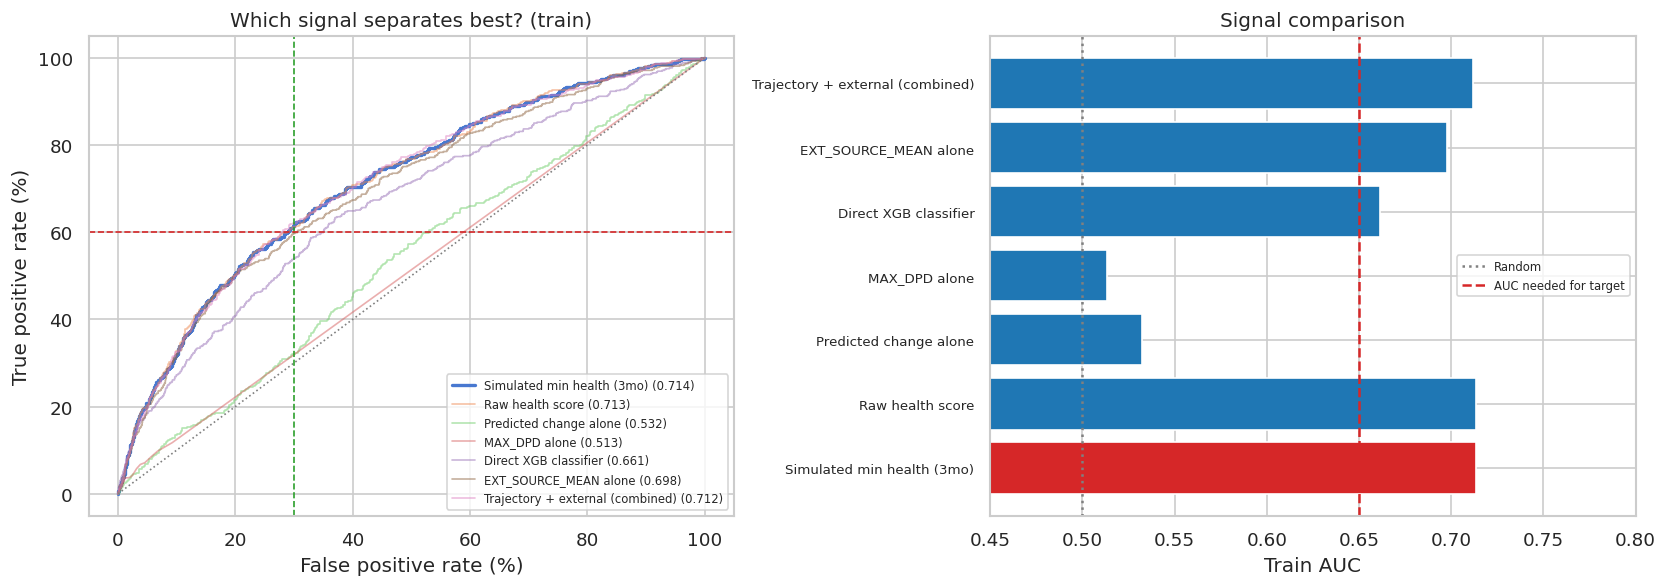

In [27]:
CALIBRATION_MONTHS = 6   # was 12. The trajectory plots showed real separation
                         # happens in months 1-3; beyond that the recursive blend
                         # mostly compounds noise, which dilutes signal rather than
                         # adding to it. Shorter horizon = less compounding.

TARGET_TPR = 0.60
MAX_FPR    = 0.30

from sklearn.metrics import roc_curve, roc_auc_score


def simulate_min_health(df_latest, velocity_model, model_features, feature_caps,
                        velocity_bounds, months=CALIBRATION_MONTHS, sample_size=None, random_state=42):
    """Minimum health reached over the horizon -- this is what the alert
    actually triggers on, so it's what we score thresholds against."""
    sample = df_latest if sample_size is None else df_latest.sample(
        n=min(sample_size, len(df_latest)), random_state=random_state)
    out = []
    for _, row in sample.iterrows():
        sim, _, _, _ = simulate_borrower(
            row["SK_ID_CURR"], row.to_dict(), velocity_model, model_features, feature_caps,
            velocity_bounds, months=months, alert_level=0.0, severe_level=0.0)
        out.append(sim["Health"].min())
    return np.array(out), sample


# =====================================================================
# SIGNAL BAKE-OFF
#
# AUC on the simulated trajectory came out at 0.568 -- barely above random.
# Before tuning anything further it's worth establishing WHICH signal
# actually separates best, because threshold tuning only slides along a
# fixed ROC curve; it cannot lift it. Each candidate below is scored on
# the same TRAIN borrowers so the comparison is like-for-like.
#
# In particular this answers whether the 3-month simulation ADDS anything
# over simply using the health score as-is. If it doesn't, that's a real
# and reportable finding, not a failure.
# =====================================================================
df_train_latest = df_train.sort_values("MONTH_BUCKET").groupby("SK_ID_CURR").last().reset_index()
df_test_latest  = df_test.sort_values("MONTH_BUCKET").groupby("SK_ID_CURR").last().reset_index()
df_test_latest["PRED_CHANGE"] = velocity_model.predict(df_test_latest[MODEL_FEATURES])
df_train_latest["PRED_CHANGE"] = velocity_model.predict(df_train_latest[MODEL_FEATURES])

train_min_health, _ = simulate_min_health(
    df_train_latest, velocity_model, MODEL_FEATURES, FEATURE_CAPS, VELOCITY_BOUNDS)
y_train_b = df_train_latest["TARGET"].values

# Direct-classification baseline.
#
# SELECTION-BIAS FIX: previously this was fit on df_train_latest and then
# SCORED on df_train_latest -- pure in-sample. It returned AUC 0.998 (pure
# memorisation), won the bake-off by construction, then collapsed to 0.66 on
# test, i.e. the worst-generalising candidate got selected. Any model scored
# on its own training rows will beat signals that aren't, so that comparison
# was never fair.
#
# Fixed with out-of-fold prediction: each borrower's score comes from a model
# that never saw that borrower during fitting, which is what the other
# candidates effectively get. Now all signals are compared like-for-like.
from sklearn.model_selection import StratifiedKFold

baseline_params = dict(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.5,
    scale_pos_weight=float((y_train_b == 0).sum() / max((y_train_b == 1).sum(), 1)),
    random_state=42, n_jobs=-1, eval_metric="auc")

train_direct = np.zeros(len(y_train_b))
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_base = df_train_latest[MODEL_FEATURES]
for tr_idx, va_idx in skf.split(X_base, y_train_b):
    fold_clf = xgb.XGBClassifier(**baseline_params)
    fold_clf.fit(X_base.iloc[tr_idx], y_train_b[tr_idx])
    train_direct[va_idx] = fold_clf.predict_proba(X_base.iloc[va_idx])[:, 1]

# Final model refit on all train data -- used only to score the test set later.
baseline_clf = xgb.XGBClassifier(**baseline_params)
baseline_clf.fit(X_base, y_train_b)

# ---------------------------------------------------------------------
# COMBINED SIGNAL.
#
# EXT_SOURCE_* are Home Credit's own external credit scores. Treating them
# as a rival to the pipeline is the wrong framing -- in a real deployment a
# lender has both an external bureau score AND its own behavioural
# monitoring, and uses them together. The external score summarises
# creditworthiness at origination; the trajectory captures how the borrower
# is behaving now. Those are complementary, not competing.
#
# So: a small logistic layer over both, fit out-of-fold on train so its
# score is honest (the same in-sample trap that broke signal selection
# earlier would otherwise apply here too).
from sklearn.model_selection import StratifiedKFold as _SKF

_combo_cols = [c for c in ["EXT_SOURCE_MEAN", "EXT_SOURCE_MIN"] if c in df_train_latest.columns]
if _combo_cols:
    X_combo_train = np.column_stack(
        [-train_min_health] + [df_train_latest[c].values for c in _combo_cols])
    train_combined = np.zeros(len(y_train_b))
    for tr_i, va_i in _SKF(n_splits=5, shuffle=True, random_state=42).split(X_combo_train, y_train_b):
        _m = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
        _m.fit(X_combo_train[tr_i], y_train_b[tr_i])
        train_combined[va_i] = _m.predict_proba(X_combo_train[va_i])[:, 1]
    combo_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
    combo_model.fit(X_combo_train, y_train_b)
    print("Combined signal weights (trajectory + external score):")
    for nm, cf in zip(["trajectory"] + _combo_cols, combo_model.coef_[0]):
        print(f"  {nm}: {cf:+.3f}")
    print()
else:
    train_combined, combo_model = None, None

candidates = {
    "Simulated min health (3mo)": -train_min_health,
    "Raw health score":           -df_train_latest["HEALTH_SCORE_SMOOTHED"].values,
    "Predicted change alone":     -df_train_latest["PRED_CHANGE"].values,
    "MAX_DPD alone":               df_train_latest["MAX_DPD_PRIOR_MONTH"].values,
    "Direct XGB classifier":       train_direct,
}
if "EXT_SOURCE_MEAN" in df_train_latest.columns:
    candidates["EXT_SOURCE_MEAN alone"] = -df_train_latest["EXT_SOURCE_MEAN"].values
if train_combined is not None:
    candidates["Trajectory + external (combined)"] = train_combined

print("SIGNAL BAKE-OFF (train AUC; direct classifier scored out-of-fold)")
print("-" * 55)
scores = {}
for name, s in candidates.items():
    try:
        scores[name] = roc_auc_score(y_train_b, s)
    except Exception as e:
        scores[name] = float("nan")
for name, auc in sorted(scores.items(), key=lambda kv: -kv[1]):
    marker = "  <-- best" if auc == max(scores.values()) else ""
    print(f"  {name:30s} {auc:.4f}{marker}")
print()

BEST_SIGNAL = max(scores, key=scores.get)
print(f"Using '{BEST_SIGNAL}' as the alert score.")
if BEST_SIGNAL != "Simulated min health (3mo)":
    print("NOTE: the simulation is NOT the strongest signal. That is a real result --")
    print("      the recursive forecast does not add separation over the simpler score.")
print()

train_score = candidates[BEST_SIGNAL]
train_auc = scores[BEST_SIGNAL]

fpr_grid, tpr_grid, neg_thr = roc_curve(y_train_b, train_score)
thresholds_grid = neg_thr

feasible = (tpr_grid >= TARGET_TPR) & (fpr_grid <= MAX_FPR)
if feasible.any():
    idx = int(np.argmax(np.where(feasible, tpr_grid, -np.inf)))
    print(f"Target reachable: TPR={tpr_grid[idx]*100:.1f}%  FPR={fpr_grid[idx]*100:.1f}%")
else:
    idx = int(np.argmin(np.abs(fpr_grid - MAX_FPR)))
    print(f"Target NOT reachable. At {MAX_FPR*100:.0f}% FPR budget, best TPR = {tpr_grid[idx]*100:.1f}% "
          f"(target {TARGET_TPR*100:.0f}%).")
    print(f"Needs AUC >= ~{(1 + TARGET_TPR - MAX_FPR)/2:.2f}; best available is {train_auc:.3f}.")

SCORE_THRESHOLD = float(thresholds_grid[idx])
idx_sev = int(np.argmin(np.abs(fpr_grid - MAX_FPR / 2)))
SEVERE_SCORE_THRESHOLD = float(thresholds_grid[idx_sev])
print(f"Score threshold: {SCORE_THRESHOLD:.4f} | severe: {SEVERE_SCORE_THRESHOLD:.4f}")

# Kept for any downstream cell still expecting health-scale levels
ALERT_LEVEL  = float(np.percentile(train_min_health, 30))
SEVERE_LEVEL = float(np.percentile(train_min_health, 10))
if ALERT_LEVEL - SEVERE_LEVEL < 0.02:
    SEVERE_LEVEL = max(0.0, ALERT_LEVEL - 0.02)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)
for name, s in candidates.items():
    f_, t_, _ = roc_curve(y_train_b, s)
    axes[0].plot(f_*100, t_*100, linewidth=2 if name == BEST_SIGNAL else 1,
                 alpha=1.0 if name == BEST_SIGNAL else 0.5,
                 label=f"{name} ({scores[name]:.3f})")
axes[0].plot([0,100],[0,100], color="gray", linestyle=":", linewidth=1)
axes[0].axvline(MAX_FPR*100, color="#2ca02c", linestyle="--", linewidth=1)
axes[0].axhline(TARGET_TPR*100, color="#d62728", linestyle="--", linewidth=1)
axes[0].set_xlabel("False positive rate (%)"); axes[0].set_ylabel("True positive rate (%)")
axes[0].set_title("Which signal separates best? (train)")
axes[0].legend(fontsize=7, loc="lower right")

names = list(scores.keys()); vals = [scores[n] for n in names]
axes[1].barh(range(len(names)), vals, color=["#d62728" if n == BEST_SIGNAL else "#1f77b4" for n in names])
axes[1].set_yticks(range(len(names))); axes[1].set_yticklabels(names, fontsize=8)
axes[1].axvline(0.5, color="gray", linestyle=":", label="Random")
axes[1].axvline((1+TARGET_TPR-MAX_FPR)/2, color="#d62728", linestyle="--", label="AUC needed for target")
axes[1].set_xlabel("Train AUC"); axes[1].set_xlim(0.45, max(0.8, max(vals)+0.05))
axes[1].set_title("Signal comparison"); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()


## Step 11: See It Work Across a Real Sample of Borrowers

A single trajectory can look convincing by accident. Instead, this simulates 15
borrowers forward at once -- a mix of confirmed defaulters and confirmed non-defaulters
pulled from the test set -- and plots every trajectory on one chart, colour-coded by
what actually happened to them. If the system is doing its job, the red (defaulted)
lines should visibly trend down toward the alert zone more than the green (did not
default) lines.

Simulating 150 borrowers forward (100 confirmed defaulters, 50 non-defaulters).


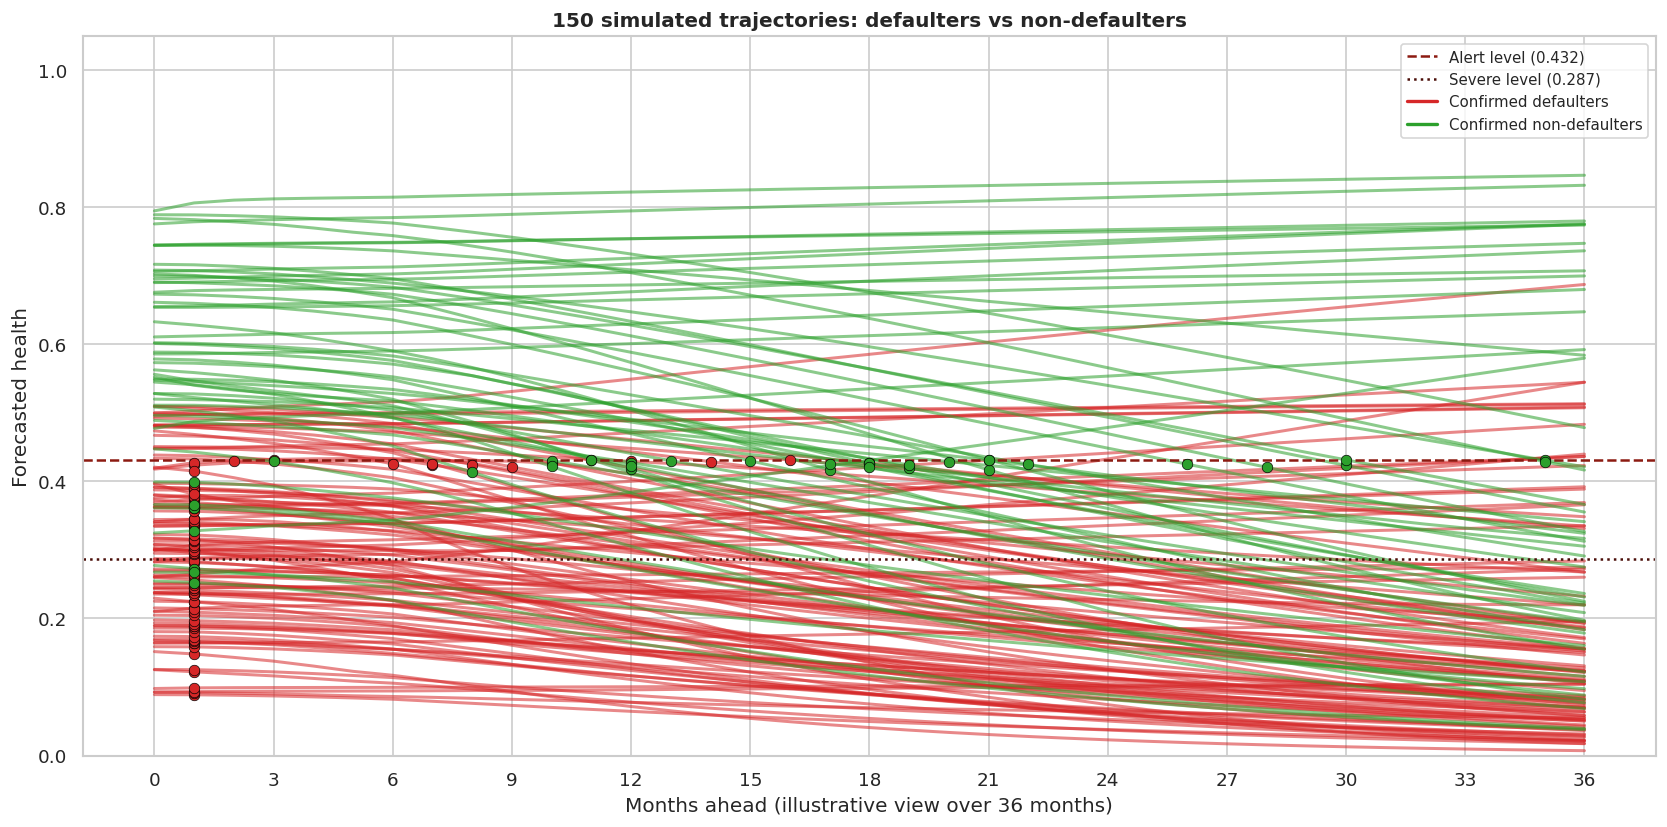

 SK_ID_CURR  Actual_Outcome  Starting_Health Alert_Month Severe_Month
   133358.0       Defaulted            0.089           1            1
   144456.0       Defaulted            0.092           1            1
   149296.0       Defaulted            0.093           1            1
   144500.0       Defaulted            0.098           1            1
   152663.0       Defaulted            0.125           1            1
   134386.0       Defaulted            0.126           1            1
   124798.0       Defaulted            0.152           1            1
   137520.0       Defaulted            0.159           1            1
   111414.0       Defaulted            0.164           1            1
   101096.0       Defaulted            0.165           1            1
   124928.0       Defaulted            0.168           1            1
   100002.0       Defaulted            0.170           1            1
   124955.0       Defaulted            0.174           1            1
   130663.0       De

In [28]:
N_TRAJECTORIES_TO_PLOT = 150
N_DEFAULTERS_IN_SAMPLE = 100  # rest filled with non-defaulters for contrast

defaulters_pool = df_test_latest[df_test_latest["TARGET"] == 1].sort_values("HEALTH_SCORE_SMOOTHED")
non_defaulters_pool = df_test_latest[df_test_latest["TARGET"] == 0].sample(
    n=min(N_TRAJECTORIES_TO_PLOT - N_DEFAULTERS_IN_SAMPLE, len(df_test_latest[df_test_latest["TARGET"] == 0])),
    random_state=42
)

chosen_defaulters = defaulters_pool.head(min(N_DEFAULTERS_IN_SAMPLE, len(defaulters_pool)))
sample_batch = pd.concat([chosen_defaulters, non_defaulters_pool]).reset_index(drop=True)

print(f"Simulating {len(sample_batch)} borrowers forward "
      f"({len(chosen_defaulters)} confirmed defaulters, {len(sample_batch) - len(chosen_defaulters)} non-defaulters).")

fig, ax1 = plt.subplots(figsize=(14, 7), dpi=120)
alert_summaries = []

for _, row in sample_batch.iterrows():
    sim, alert_month, alert_health, severe_month = simulate_borrower(
        row["SK_ID_CURR"], row.to_dict(), velocity_model, MODEL_FEATURES, FEATURE_CAPS, VELOCITY_BOUNDS,
        months=SIMULATION_MONTHS, alert_level=ALERT_LEVEL, severe_level=SEVERE_LEVEL
    )
    is_defaulter = row["TARGET"] == 1
    color = "#d62728" if is_defaulter else "#2ca02c"
    ax1.plot(sim["Month"], sim["Health"], color=color, alpha=0.55, linewidth=1.8)

    if alert_month is not None:
        ax1.scatter([alert_month], [alert_health], color=color, s=40, zorder=5, edgecolor="black", linewidth=0.4)

    alert_summaries.append({
        "SK_ID_CURR": row["SK_ID_CURR"],
        "Actual_Outcome": "Defaulted" if is_defaulter else "Did not default",
        "Starting_Health": round(row["HEALTH_SCORE_SMOOTHED"], 3),
        "Alert_Month": alert_month if alert_month is not None else "-",
        "Severe_Month": severe_month if severe_month is not None else "-"
    })

ax1.axhline(ALERT_LEVEL, color="#8c1a11", linestyle="--", linewidth=1.5, label=f"Alert level ({ALERT_LEVEL:.3f})")
ax1.axhline(SEVERE_LEVEL, color="#4a0d08", linestyle=":", linewidth=1.5, label=f"Severe level ({SEVERE_LEVEL:.3f})")
ax1.plot([], [], color="#d62728", linewidth=2, label="Confirmed defaulters")
ax1.plot([], [], color="#2ca02c", linewidth=2, label="Confirmed non-defaulters")

ax1.set_xlabel(f"Months ahead (illustrative view over {SIMULATION_MONTHS} months)")
ax1.set_ylabel("Forecasted health")
ax1.set_ylim(0.0, 1.05)
ax1.set_xticks(np.arange(0, SIMULATION_MONTHS + 1, 3))
ax1.legend(loc="upper right", fontsize=9)
plt.title(f"{len(sample_batch)} simulated trajectories: defaulters vs non-defaulters", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

summary_table = pd.DataFrame(alert_summaries)
print(summary_table.to_string(index=False))

## Step 12: Check the Simulation Against What Actually Happened

For borrowers with enough real history, we can start the simulation at their first
observed month and compare the forecast against what they actually did -- a genuine
out-of-sample check, not just a plausibility check.

In [29]:
def check_against_history(df_test, velocity_model, model_features, feature_caps, velocity_bounds,
                          alert_level, severe_level, sample_size=None, min_months=5):
    # sample_size=None means evaluate every eligible borrower, not a small subsample.
    results = []
    eligible = df_test.groupby("SK_ID_CURR").filter(lambda x: len(x) >= min_months)
    groups = list(eligible.groupby("SK_ID_CURR"))
    np.random.shuffle(groups)
    groups_to_use = groups if sample_size is None else groups[:sample_size]

    for b_id, group in groups_to_use:
        group = group.sort_values("MONTH_BUCKET").reset_index(drop=True)
        starting_state = group.iloc[0].to_dict()
        n_steps = len(group) - 1
        actual = group["HEALTH_SCORE_SMOOTHED"].values[1:]

        sim, _, _, _ = simulate_borrower(b_id, starting_state, velocity_model, model_features,
                                         feature_caps, velocity_bounds, months=n_steps,
                                         alert_level=alert_level, severe_level=severe_level)
        forecast = sim["Health"].values[1:]
        n = min(len(actual), len(forecast))
        error = np.mean(np.abs(actual[:n] - forecast[:n]))

        results.append({"SK_ID_CURR": b_id, "TARGET": group["TARGET"].iloc[0],
                        "Months_Observed": n_steps, "Avg_Error": round(error, 4),
                        "Final_Actual": round(actual[-1], 4), "Final_Forecast": round(forecast[n-1], 4)})

    return pd.DataFrame(results).sort_values("Avg_Error").reset_index(drop=True)


history_check = check_against_history(df_test, velocity_model, MODEL_FEATURES, FEATURE_CAPS,
                                      VELOCITY_BOUNDS, ALERT_LEVEL, SEVERE_LEVEL)  # full eligible test set

print(f"Median forecast error: {history_check['Avg_Error'].median():.4f}")
print(f"Mean forecast error: {history_check['Avg_Error'].mean():.4f}")
print(history_check.to_string(index=False))

Median forecast error: 0.0173
Mean forecast error: 0.0220
 SK_ID_CURR  TARGET  Months_Observed  Avg_Error  Final_Actual  Final_Forecast
     123671       0                4     0.0012        0.5102          0.5077
     121824       0                4     0.0012        0.6511          0.6521
     152584       0                4     0.0015        0.7218          0.7225
     123471       0                4     0.0015        0.8288          0.8276
     133086       1                5     0.0016        0.6855          0.6894
     115057       0                4     0.0017        0.4251          0.4224
     130999       0                4     0.0018        0.1540          0.1505
     104966       0                6     0.0020        0.6485          0.6499
     115092       0                6     0.0020        0.4463          0.4492
     131639       0                4     0.0020        0.7814          0.7814
     122990       0                4     0.0021        0.7013          0.7020
     1

## Step 13: Test Whether the Alert Actually Catches Defaulters

The real test of an early-warning system: does it fire more often, and earlier, for
borrowers who actually go on to default -- compared to those who don't?

TEST AUC across all candidate signals
-------------------------------------------------------
  Raw health score               0.7333
  Trajectory + external (combined) 0.7302
  Simulated min health (3mo)     0.7300  <-- selected on train
  EXT_SOURCE_MEAN alone          0.7220
  Direct XGB classifier          0.7073
  MAX_DPD alone                  0.5178
  Predicted change alone         0.4961

Test set: 1673 borrowers (138 defaulters)
  Signal used:        Simulated min health (3mo)
  Detection (TPR):    64.5%   target >= 60%
  False positives:    30.1%   target <  30%
  Precision:          16.2%  (base rate 8.2%)
  Lift:               1.96x
  Test AUC:           0.7300  (train 0.7136)

Detection met; FPR 0.1 points over budget.

Combined vs components (test AUC):
  Trajectory alone:            0.7300
  External score alone:        0.7220
  Combined:                    0.7302   (+0.0002 vs best component)


NOTE: 'Simulated min health (3mo)' was selected on train, but 'Raw health sc

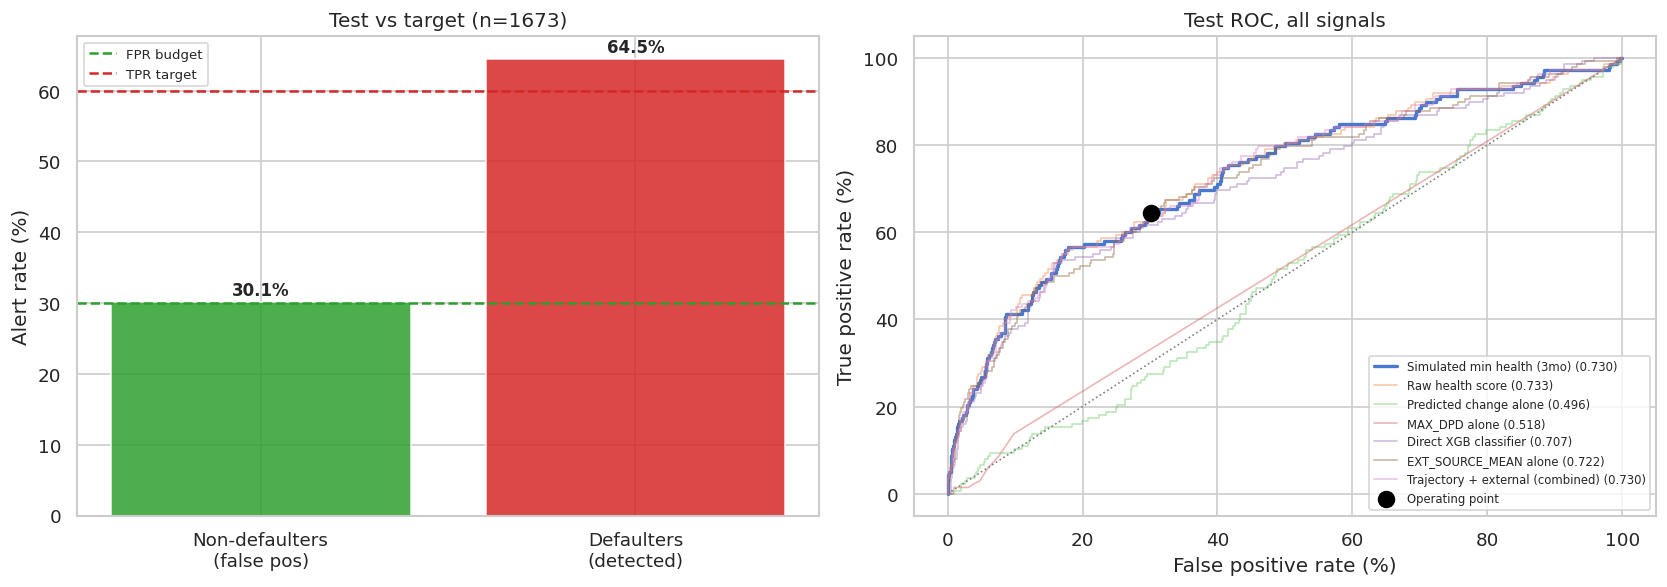

In [30]:
# =====================================================================
# TEST EVALUATION -- uses whichever signal won the bake-off, scored with
# the threshold selected on TRAIN. Nothing here is fit or chosen on test.
# =====================================================================

test_min_health, _ = simulate_min_health(
    df_test_latest, velocity_model, MODEL_FEATURES, FEATURE_CAPS, VELOCITY_BOUNDS)
y_test_b = df_test_latest["TARGET"].values

test_candidates = {
    "Simulated min health (3mo)": -test_min_health,
    "Raw health score":           -df_test_latest["HEALTH_SCORE_SMOOTHED"].values,
    "Predicted change alone":     -df_test_latest["PRED_CHANGE"].values,
    "MAX_DPD alone":               df_test_latest["MAX_DPD_PRIOR_MONTH"].values,
    "Direct XGB classifier":       baseline_clf.predict_proba(df_test_latest[MODEL_FEATURES])[:, 1],
}
if "EXT_SOURCE_MEAN" in df_test_latest.columns:
    test_candidates["EXT_SOURCE_MEAN alone"] = -df_test_latest["EXT_SOURCE_MEAN"].values
if combo_model is not None:
    X_combo_test = np.column_stack(
        [-test_min_health] + [df_test_latest[c].values for c in _combo_cols])
    test_candidates["Trajectory + external (combined)"] = combo_model.predict_proba(X_combo_test)[:, 1]

print("TEST AUC across all candidate signals")
print("-" * 55)
test_scores = {n: roc_auc_score(y_test_b, s) for n, s in test_candidates.items()}
for n, a in sorted(test_scores.items(), key=lambda kv: -kv[1]):
    flag = "  <-- selected on train" if n == BEST_SIGNAL else ""
    print(f"  {n:30s} {a:.4f}{flag}")
print()

test_score = test_candidates[BEST_SIGNAL]
test_auc   = test_scores[BEST_SIGNAL]

alert_fired  = test_score >= SCORE_THRESHOLD
severe_fired = test_score >= SEVERE_SCORE_THRESHOLD

tpr = alert_fired[y_test_b == 1].mean() if (y_test_b == 1).any() else float("nan")
fpr = alert_fired[y_test_b == 0].mean() if (y_test_b == 0).any() else float("nan")
n_flagged = alert_fired.sum()
precision = (y_test_b[alert_fired] == 1).sum() / n_flagged if n_flagged > 0 else float("nan")
base_rate = y_test_b.mean()

print(f"Test set: {len(y_test_b)} borrowers ({int((y_test_b==1).sum())} defaulters)")
print(f"  Signal used:        {BEST_SIGNAL}")
print(f"  Detection (TPR):    {tpr*100:.1f}%   target >= {TARGET_TPR*100:.0f}%")
print(f"  False positives:    {fpr*100:.1f}%   target <  {MAX_FPR*100:.0f}%")
print(f"  Precision:          {precision*100:.1f}%  (base rate {base_rate*100:.1f}%)")
print(f"  Lift:               {precision/base_rate:.2f}x")
print(f"  Test AUC:           {test_auc:.4f}  (train {train_auc:.4f})")
print()

if tpr >= TARGET_TPR and fpr < MAX_FPR:
    print("TARGET MET on test.")
elif fpr < MAX_FPR:
    print(f"FPR within budget; detection {(TARGET_TPR-tpr)*100:.1f} points short.")
elif tpr >= TARGET_TPR:
    print(f"Detection met; FPR {(fpr-MAX_FPR)*100:.1f} points over budget.")
else:
    print("Neither target met.")

if abs(test_auc - train_auc) > 0.05:
    print(f"\nWarning: train/test AUC differ by {abs(test_auc-train_auc):.3f} -- threshold may not transfer.")

if "Trajectory + external (combined)" in test_scores:
    _c = test_scores["Trajectory + external (combined)"]
    _t = test_scores["Simulated min health (3mo)"]
    _e = test_scores.get("EXT_SOURCE_MEAN alone", float("nan"))
    print()
    print("Combined vs components (test AUC):")
    print(f"  Trajectory alone:            {_t:.4f}")
    print(f"  External score alone:        {_e:.4f}")
    print(f"  Combined:                    {_c:.4f}   "
          f"({_c - max(_t, _e):+.4f} vs best component)")

sim_auc_test = test_scores["Simulated min health (3mo)"]
raw_auc_test = test_scores["Raw health score"]
print()


# ---------------------------------------------------------------------
# Would a different signal have been the better choice on test?
# Selection happens on train (correctly), but it's worth surfacing when
# train and test disagree -- that's a generalisation warning, and it's
# exactly what the earlier in-sample selection bug produced.
# ---------------------------------------------------------------------
best_on_test = max(test_scores, key=test_scores.get)
if best_on_test != BEST_SIGNAL:
    print()
    print(f"NOTE: '{BEST_SIGNAL}' was selected on train, but '{best_on_test}' "
          f"scores higher on test ({test_scores[best_on_test]:.4f} vs {test_auc:.4f}).")
    print("      Train and test disagree on ranking -- treat the selected signal with caution.")

# ---------------------------------------------------------------------
# EXT_SOURCE_* are Home Credit's own pre-computed external credit scores.
# They're legitimately available at prediction time, but a large share of
# performance coming from them means the lift reflects their model more
# than this pipeline. Report both so the contribution stays legible.
# ---------------------------------------------------------------------
ext_cols = [c for c in ["EXT_SOURCE_MEAN", "EXT_SOURCE_MIN", "EXT_SOURCE_MISSING"] if c in MODEL_FEATURES]
if ext_cols:
    feats_no_ext = [c for c in MODEL_FEATURES if c not in ext_cols]
    clf_no_ext = xgb.XGBClassifier(**baseline_params)
    clf_no_ext.fit(df_train_latest[feats_no_ext], y_train_b)
    auc_no_ext = roc_auc_score(y_test_b, clf_no_ext.predict_proba(df_test_latest[feats_no_ext])[:, 1])
    auc_with_ext = test_scores["Direct XGB classifier"]
    print()
    print("Contribution of Home Credit's own external scores (EXT_SOURCE_*):")
    print(f"  Direct classifier WITH ext scores:    {auc_with_ext:.4f}")
    print(f"  Direct classifier WITHOUT ext scores: {auc_no_ext:.4f}")
    print(f"  Attributable to EXT_SOURCE_*:         {auc_with_ext - auc_no_ext:+.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)
bars = axes[0].bar(["Non-defaulters\n(false pos)", "Defaulters\n(detected)"],
                   [fpr*100, tpr*100], color=["#2ca02c", "#d62728"], alpha=0.85)
axes[0].axhline(MAX_FPR*100, color="#2ca02c", linestyle="--", linewidth=1.5, label=f"FPR budget")
axes[0].axhline(TARGET_TPR*100, color="#d62728", linestyle="--", linewidth=1.5, label=f"TPR target")
axes[0].set_ylabel("Alert rate (%)"); axes[0].set_title(f"Test vs target (n={len(y_test_b)})")
axes[0].legend(fontsize=8)
for b, r in zip(bars, [fpr*100, tpr*100]):
    axes[0].text(b.get_x()+b.get_width()/2, r+1, f"{r:.1f}%", ha="center", fontweight="bold")

for n, s in test_candidates.items():
    f_, t_, _ = roc_curve(y_test_b, s)
    axes[1].plot(f_*100, t_*100, linewidth=2 if n == BEST_SIGNAL else 1,
                 alpha=1.0 if n == BEST_SIGNAL else 0.45,
                 label=f"{n} ({test_scores[n]:.3f})")
axes[1].plot([0,100],[0,100], color="gray", linestyle=":", linewidth=1)
axes[1].scatter([fpr*100],[tpr*100], color="black", s=90, zorder=5, label="Operating point")
axes[1].set_xlabel("False positive rate (%)"); axes[1].set_ylabel("True positive rate (%)")
axes[1].set_title("Test ROC, all signals"); axes[1].legend(fontsize=7, loc="lower right")
plt.tight_layout(); plt.show()

alert_check = pd.DataFrame({
    "SK_ID_CURR": df_test_latest["SK_ID_CURR"].values,
    "TARGET": y_test_b, "Alert_Fired": alert_fired,
    "Severe_Fired": severe_fired, "Min_Health": test_min_health,
})


## Step 14: Estimate How Much We'll Actually Recover Next Month

This is the payoff -- the same move the industrial project made when it turned a
degradation forecast into a maintenance recommendation. Here, we turn a health forecast
into an actual dollar estimate: given where we expect a borrower's health to be next
month, how much of their next payment do we realistically expect to collect?

We map forecasted health to an expected payment ratio using a simple, monotonic curve
fit on train data only (higher health should never imply a *lower* expected payment --
that constraint is built in, not just hoped for), multiply by the typical amount they
owe, and total it up across the batch of accounts flagged as most at risk.

Expected payment ratio at a few health levels:
  Health = 0.1  ->  expected payment ratio = 0.890
  Health = 0.5  ->  expected payment ratio = 0.945
  Health = 0.9  ->  expected payment ratio = 1.000

EXPECTED RECOVERY -- NEXT INSTALLMENT, AT-RISK ACCOUNTS
 SK_ID_CURR Actual_Outcome  Current_Health  Forecasted_Next_Health  Amount_Due  Expected_Payment_Ratio  Expected_Recovery  Expected_Shortfall  Alert_Fires_At
   133358.0      Defaulted           0.089                   0.089    20832.53                   0.822           17114.01             3718.52               1
   144456.0      Defaulted           0.092                   0.092     8955.62                   0.822            7357.08             1598.54               1
   149296.0      Defaulted           0.093                   0.093     4201.39                   0.822            3451.46              749.93               1
   144500.0      Defaulted           0.098                   0.099    13607.32                   0.890         

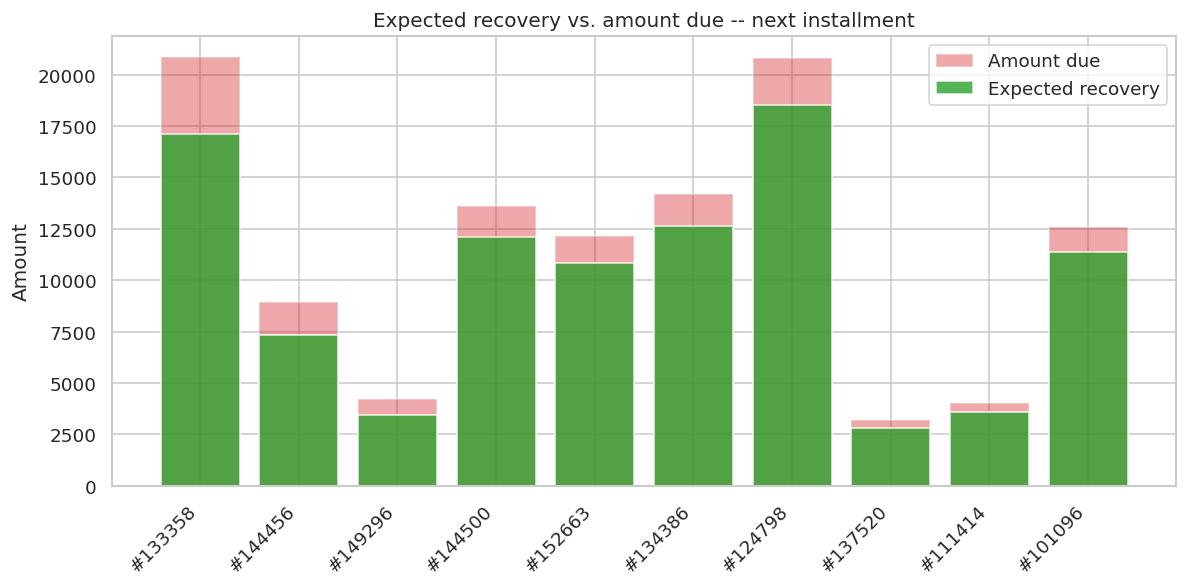

In [31]:
# Monotonic mapping: forecasted health -> expected payment ratio, fit on train only
recovery_model = IsotonicRegression(y_min=0, y_max=1.5, increasing=True, out_of_bounds="clip")
recovery_model.fit(df_train["HEALTH_SCORE_SMOOTHED"].values, df_train["AVG_PAYMENT_RATIO"].values)

print("Expected payment ratio at a few health levels:")
for h in [0.1, 0.5, 0.9]:
    print(f"  Health = {h:.1f}  ->  expected payment ratio = {recovery_model.predict([h])[0]:.3f}")

typical_installment = df_test_raw.groupby("SK_ID_CURR")["AMT_INSTALMENT"].mean().rename("TYPICAL_AMOUNT_DUE")

at_risk_batch = df_test_latest[df_test_latest["TARGET"] == 1].sort_values("HEALTH_SCORE_SMOOTHED").head(10)
if len(at_risk_batch) < 10:
    fillers = df_test_latest[df_test_latest["TARGET"] == 0].sort_values("HEALTH_SCORE_SMOOTHED").head(10 - len(at_risk_batch))
    at_risk_batch = pd.concat([at_risk_batch, fillers])

at_risk_batch = at_risk_batch.merge(typical_installment, on="SK_ID_CURR", how="left")
at_risk_batch["TYPICAL_AMOUNT_DUE"] = at_risk_batch["TYPICAL_AMOUNT_DUE"].fillna(df_test_raw["AMT_INSTALMENT"].mean())

recovery_rows = []
for _, row in at_risk_batch.iterrows():
    sim, alert_m, _, _ = simulate_borrower(row["SK_ID_CURR"], row.to_dict(), velocity_model,
                                           MODEL_FEATURES, FEATURE_CAPS, VELOCITY_BOUNDS, months=1)
    next_month_health = sim.iloc[1]["Health"]
    expected_ratio = float(np.clip(recovery_model.predict([next_month_health])[0], 0.0, 1.0))
    amount_due = row["TYPICAL_AMOUNT_DUE"]
    expected_recovery = expected_ratio * amount_due

    recovery_rows.append({
        "SK_ID_CURR": row["SK_ID_CURR"], "Actual_Outcome": "Defaulted" if row["TARGET"] == 1 else "Did not default",
        "Current_Health": round(row["HEALTH_SCORE_SMOOTHED"], 3),
        "Forecasted_Next_Health": round(next_month_health, 3),
        "Amount_Due": round(amount_due, 2),
        "Expected_Payment_Ratio": round(expected_ratio, 3),
        "Expected_Recovery": round(expected_recovery, 2),
        "Expected_Shortfall": round(amount_due - expected_recovery, 2),
        "Alert_Fires_At": alert_m if alert_m is not None else "-"
    })

recovery_table = pd.DataFrame(recovery_rows)
total_due = recovery_table["Amount_Due"].sum()
total_recovery = recovery_table["Expected_Recovery"].sum()
total_shortfall = recovery_table["Expected_Shortfall"].sum()
recovery_pct = total_recovery / total_due * 100 if total_due > 0 else float("nan")

print()
print("" + "="*90)
print("EXPECTED RECOVERY -- NEXT INSTALLMENT, AT-RISK ACCOUNTS")
print("="*90)
print(recovery_table.to_string(index=False))
print("-"*90)
print(f"Total amount due next installment:  {total_due:,.2f}")
print(f"Total expected recovery:            {total_recovery:,.2f}  ({recovery_pct:.1f}% of what's owed)")
print(f"Total expected shortfall:           {total_shortfall:,.2f}")
print("="*90)
print()
print("This is the number a collections team would use to prioritise outreach BEFORE "
      "the payment is due -- not after it's already been missed.")

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
x_pos = np.arange(len(recovery_table))
ax.bar(x_pos, recovery_table["Amount_Due"], color="#d62728", alpha=0.4, label="Amount due")
ax.bar(x_pos, recovery_table["Expected_Recovery"], color="#2ca02c", alpha=0.8, label="Expected recovery")
ax.set_xticks(x_pos)
ax.set_xticklabels([f"#{int(i)}" for i in recovery_table["SK_ID_CURR"]], rotation=45, ha="right")
ax.set_ylabel("Amount")
ax.set_title("Expected recovery vs. amount due -- next installment")
ax.legend()
plt.tight_layout()
plt.show()